In [1]:
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility

import sncosmo

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"]

from lsst_functions import set_selection_criteria
selection_criteria = set_selection_criteria(total_points=5,n_filters=2,min_points_per_filter=2)

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## TO DO 24 Jul 2026 / 06 Aug 2026
Remember: use random population to generate the event!
ref docs: https://skysurvey.readthedocs.io/en/latest/howto/load_lsst.html

1. Find coverage each night. Plot different nights.


After finding which points are detected, find the respective window

In [2]:
opsim_path = "baseline_v5.3.5_10yrs.db" # provide fullpath
# opsim_path = "Surveys/baseline_v5.3.5_10yrs.db:Zone.Identifier"
lsst = skysurvey.LSST.from_opsim(opsim_path, sql_where="night < 365")
# if you want to choose only one band: band IN ('g') AND 
# IMPOTANT: remove the _## from the band names in the lsst observation
lsst.data["band"] = (lsst.data["band"].str.replace(r"_\d+$", "", regex=True))
lsst.data["band"].unique()

<ArrowStringArray>
['lsstu', 'lsstr', 'lsstg', 'lssti', 'lsstz', 'lssty']
Length: 6, dtype: str

In [2]:
from skysurvey.config import get_band_color
import inspect
print(inspect.getsource(get_band_color))
help(get_band_color)

def get_band_color(bands, fill_value=None):
    """Get the color of the given bands.

    Parameters
    ----------
    bands: str or list of str
        Band or list of bands.
    fill_value: str or None, optional
        Value to fill if the band is not found.

    Returns
    -------
    str or list
        Color or list of colors.
    """
    squeeze = isinstance(bands, (str, np.str_))
    colors = [BAND_COLORS.get(band_, fill_value) for band_ in np.atleast_1d(bands)]
    return colors if not squeeze else colors[0]

Help on function get_band_color in module skysurvey.config:

get_band_color(bands, fill_value=None)
    Get the color of the given bands.

    Parameters
    ----------
    bands: str or list of str
        Band or list of bands.
    fill_value: str or None, optional
        Value to fill if the band is not found.

    Returns
    -------
    str or list
        Color or list of colors.



### Load LSST filepath
It can take a while to load. Note that you need toremove the suffixes from the band names.

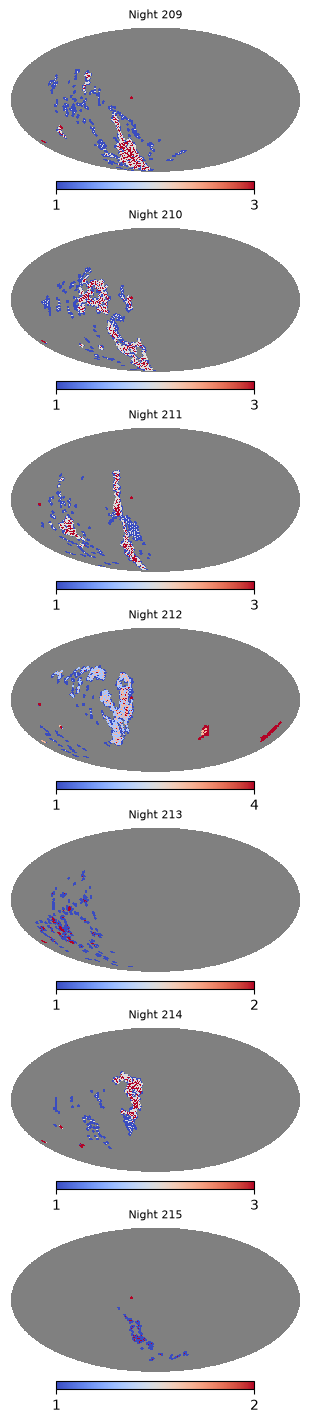

In [7]:
from lsst_functions import visualize_nights
visualize_nights(opsim_path, start_night=209, stop_night=216)

#### Plot nightly coverage and data
lsst_filter_designations = ['lsstu_24', 'lsstr_57', 'lsstg_6', 'lssti_39', 'lsstz_20', 'lssty_10']

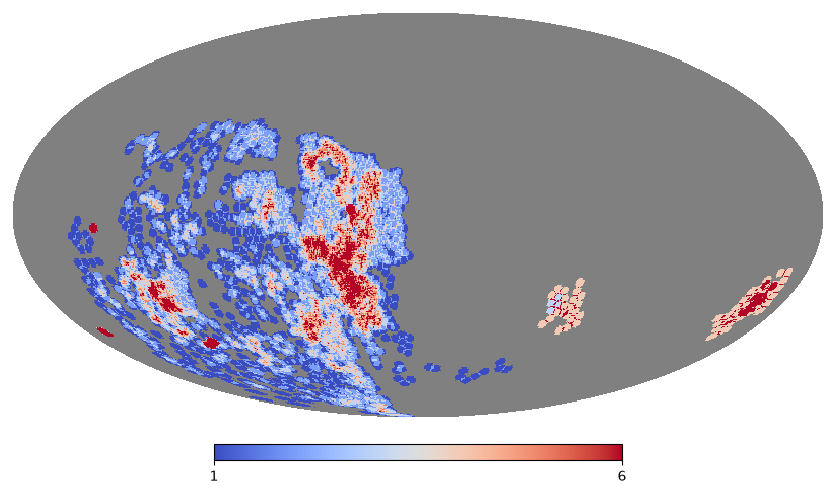

In [6]:
night_211 = skysurvey.LSST.from_opsim(opsim_path, sql_where= f"night >= 211 AND night < 221")
coverage_211 = night_211.get_fieldcoverage(incl_zeros=True)
night_211.show(vmin=0, vmax=coverage_211.quantile(0.95), cmap="coolwarm")

In [8]:
from astropy.time import Time
tmin_test, tmax_test = night_211.date_range
print(f"Start: {Time(tmin_test, format='mjd').iso}")
print(f"End:   {Time(tmax_test, format='mjd').iso}")
print(f"Duration: {(tmax_test - tmin_test)/365.25:.1f} years")
night_211.date_range

NameError: name 'night_211' is not defined

In [ ]:
print('fieldids with NaN value', coverage_211.isna().sum(),'| fieldids non-zero', coverage_211.notna().sum(), 'out of' , len(coverage_211)
      '\n min non-zero/max:', coverage_211.values.min(),  coverage_211.values.max())

fieldids with NaN value 452332 | fieldids non-zero 27668 out of 480000


In [39]:
coverage_211[coverage_211.values >= 0]

fieldid
118111    1.0
118112    1.0
118113    1.0
118114    1.0
118115    1.0
         ... 
478813    1.0
478814    1.0
478815    1.0
478816    1.0
478817    1.0
Length: 27668, dtype: float64

In [ ]:
# plot every five nights
for i in np.arange(2, 18, 5):
    night = skysurvey.LSST.from_opsim(opsim_path, sql_where= f"night >= {i} AND night < {i+5}")
    coverage = night.get_fieldcoverage()
    print(f'number of non-zero fieldids for {i} to {i+5}:', len(coverage.index))
    night.show(vmin=0, vmax=coverage.quantile(0.95), cmap="coolwarm", title = f'Night {i} to {i+5}')

In [5]:
lsst.data.columns

Index(['skynoise', 'mjd', 'band', 'gain', 'zp', 'ra', 'dec', 'observationId',
       'fieldid_survey', 'fieldid'],
      dtype='str')

In [ ]:
lsst.data #gives all info about the observation over the 1 year (e.g skynoise and in what band)
# left column is an exposure (in a certain obs_id/fieldid_survey), pointing at a particular field_ids

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
0,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474007
1,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474008
2,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474009
3,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474010
4,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474011
...,...,...,...,...,...,...,...,...,...,...
19171321,36.069012,61566.074219,lsstr,1,30,196.431473,-47.600517,172627,172627,421827
19171322,36.069012,61566.074219,lsstr,1,30,196.431473,-47.600517,172627,172627,421828
19171323,36.069012,61566.074219,lsstr,1,30,196.431473,-47.600517,172627,172627,421829
19171324,36.069012,61566.074219,lsstr,1,30,196.431473,-47.600517,172627,172627,421830


/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2014 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


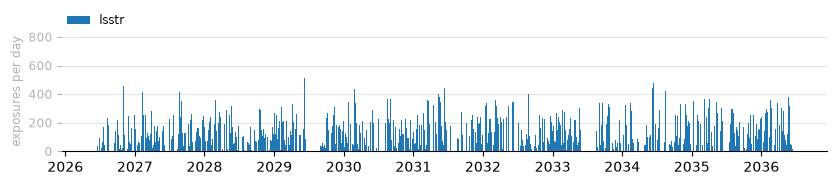

In [3]:
fig = lsst.show_nexposures(exposure_key="observationId") #observationId is LSST's specific exposure_key
# and each exposure is for a certain number of minutes (usually five)

# (lsst.data["observationId"] == lsst.data["fieldid_survey"]).all() # should be true in our case. why?

In [ ]:
lsst.data[lsst.data['fieldid'] == 474009] #some have more observations than another
# as ['observationId'] increases, goes from u --> g --> r --> i --> z --> y
# fieldids can be duplicated too. this means that the same field was re-visited during different exposures

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
2,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474009
729,71.667374,61208.203125,lsstu,1,30,265.602020,-77.358208,6,6,474009
1331,81.148010,61208.207031,lsstu,1,30,264.967010,-75.771973,11,11,474009
71531,94.095505,61209.132812,lsstu,1,30,260.472870,-76.249313,646,646,474009
479061,356.150421,61218.113281,lssty,1,30,263.992859,-75.561653,4315,4315,474009
712431,294.086578,61220.253906,lssty,1,30,268.981934,-77.110123,6417,6417,474009
716982,171.078552,61220.273438,lsstz,1,30,263.344421,-78.683006,6458,6458,474009
943122,200.201218,61226.015625,lsstz,1,30,258.859924,-78.667793,8503,8503,474009
1064015,57.544468,61227.054688,lsstr,1,30,265.298004,-78.184036,9595,9595,474009
1068970,54.989235,61227.074219,lsstr,1,30,265.698242,-77.884766,9639,9639,474009


In [ ]:
# differneces between cadences(exposures)
mjd_list = lsst.data["mjd"].unique() # mjd_list
diffs = []
for i in range(5):
    diff = mjd_list[i+1] - mjd_list[i]
    diffs.append(diff * 1440)

print("diff  (in minutes) is")
diffs

diff  (in minutes) is


[np.float32(5.625),
 np.float32(5.625),
 np.float32(67.5),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625)]

In [3]:
# if you wan to vary time, 
from astropy.time import Time
tmin, tmax = lsst.date_range
print(f"Start: {Time(tmin, format='mjd').iso}")
print(f"End:   {Time(tmax, format='mjd').iso}")
print(f"Duration: {(tmax - tmin)/365.25:.1f} years")
lsst.date_range

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years


(np.float32(61208.203), np.float32(61566.074))

In [7]:
snia_dict = generate_snia_dict(redshift = 0.2, ra = None, dec = None, x1 = 0.0, t0 = None, magabs = -18.523, c = 0.0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = False, N_tot = 100, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
snia_models.template.get().maxtime()

CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x76dee49d47d0>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 100, 'value': 0.2}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 100, 'value': 0.0}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 100, 'value': 0.0}, 'as': 'c'}, 'magabs': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 100, 'value': -18.523}, 'as': 'magabs'}}


np.float64(50.0)

In [39]:
snia_models.data.loc[0]

z                    0.2
x1                   0.0
c                    0.0
t0          61475.882812
magabs        -18.523001
ra             32.967373
dec              4.00172
magobs         21.503532
template           salt2
Name: 0, dtype: object

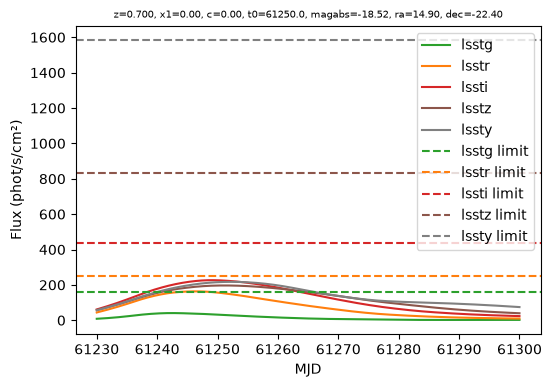

In [85]:
from lightcurve import plot_lightcurve
model = data_models[8]
plot_lightcurve(model, times=model['times'], in_mag = False)

In [ ]:
model['lc_by_band']['lssty']

In [ ]:
coverage = lsst.get_fieldcoverage()
lsst.show(vmin=0, vmax=coverage.quantile(0.95), cmap="coolwarm")

In [134]:
coverage[coverage == coverage.quantile(0.95)].index[1600] #336769

np.int32(336769)

In [44]:
select_fieldid = (lsst.data['fieldid'] == 336769)
lsst.data[select_fieldid]
#notice that the skynoise keeps changing

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
746516,196.659775,61220.398438,lssty,1,30,15.118820,-24.520018,6728,6728,336769
747279,193.938110,61220.402344,lssty,1,30,13.439541,-24.830439,6735,6735,336769
748027,187.444550,61220.406250,lssty,1,30,14.914061,-22.415033,6741,6741,336769
2490977,174.023254,61249.308594,lssty,1,30,15.000562,-25.385891,22488,22488,336769
2493145,166.187485,61249.316406,lssty,1,30,12.824963,-23.767998,22507,22507,336769
...,...,...,...,...,...,...,...,...,...,...
11733574,529.284485,61455.027344,lsstz,1,30,13.848436,-23.457905,105804,105804,336769
11873313,235.430984,61459.015625,lsstr,1,30,14.848493,-22.415325,107059,107059,336769
11874778,234.476791,61459.019531,lsstr,1,30,14.848493,-22.415325,107072,107072,336769
11876243,214.955368,61459.019531,lsstr,1,30,14.848493,-22.415325,107085,107085,336769


<code>get_fieldcoverage()</code> returns the number of observations per field. Passing it to <code>show()</code> via vmax controls the color scale. In this example, we use the 95th percentile to enhance the constrast between fields that receive a high number of visits (e.g. deep drilling fields, overlap regions) and less-covered regions.

Once you simulated N_tot supernovae, the <code> .from_targets_and_survey() </code> function simulates the observation plan and sees if our SN are visible.
10/8/2026: Recall at ALL the SN are assumed to be at the same spot; so the fieldids where they are found in should match up.

Functions:

<code>get_targetlightcurve(index = ...)</code> gives a dataframe of diff index_obs with columns: field params.

In [ ]:
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
#discard_bands remove those which spectra do not fall within bands due to redshift

100%|██████████| 65/65 [00:05<00:00, 12.08it/s]


In [41]:
dset.data.loc[0]

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr
index_obs,,,,,,,,
19060840,61563.429688,lsstr,140.992416,1,30,223127,248.934885,140.992416
19062269,61563.433594,lsstr,178.634644,1,30,223127,5.109779,178.634644
19063698,61563.437500,lsstr,166.536652,1,30,223127,61.971032,166.536654
19065127,61563.441406,lsstr,203.898056,1,30,223127,-318.423914,203.898058


In [26]:
dset.get_ndetection(per_band = True).loc[0]
#same target but at what redshift? for the part of N detected points in lc, we can only simulate ONE.
# isn't it useless if you keep everything fixed for N_to = 1000? You need to vary t0.

band
lssti    5
lsstr    5
lssty    1
lsstz    1
dtype: int64

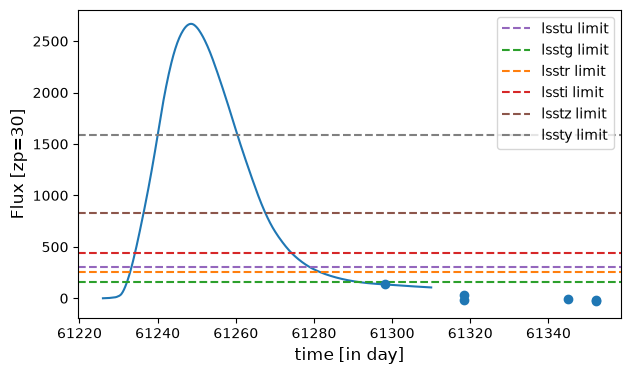

In [ ]:
# this is a good example. keep in the slides
dset.show_target_lightcurve(index = 6, phase_window=[-60,200], zp = 30, bands = ['lsstg'], format_time = False)
# plt.xlim(61321, 61322)
ax = plt.gca()
for band in bands:
    ax.axhline(
        limit_mag_dict[band]["flux"],
        color=limit_mag_dict[band]["color"],
        linestyle="--",
        label=f"{band} limit",
    )
ax.legend()

From these, you want to build a dataframe of all the observations.
pandas.DataFrame format:

Blank | filters ..... | ..... |
Cond 1   1, 0, or -1 depending on visiblity (already possible using determine_visiblity())
Cond 2   same
Cond 3   same

In [3]:
from lightcurve import limit_mag_dict

def get_band_data(target_data, band = None):
    # for observation dataset of one target
    return target_data[target_data['band'] == band]

def get_unique_bands(target_data):
    return target_data['flux'].unique()

In [11]:
data = dset.get_ndetection(per_band = True)
data.loc[0]
# for general detected or not detected
indiv_data = data.loc[0]
indiv_data.sum()

np.int64(12)

In [ ]:
indiv_sorted = indiv_data.sort_values(ascending=False)
# (indiv_sorted.iloc[0] >= 2) & (indiv_sorted.iloc[1] >= 2)
#check len(sorted) >= 2:
# print(0 if ((indiv_sorted.iloc[0] >= 2) & (indiv_sorted.iloc[1] >= 2)) else 1)


In [13]:
detection_rows = dset.get_data(index=0,detection=True)
detection_rows

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr
index_obs,,,,,,,,
2770824,61261.406250,lsstr,24.485266,1,30,331967,8124.716923,94.037198
2772648,61261.421875,lsstr,24.718338,1,30,331967,8269.751369,94.062761
2860934,61262.421875,lssti,57.493050,1,30,331967,5044.718328,91.954351
3332454,61269.425781,lsstr,48.146404,1,30,331967,5497.433271,88.836000
3429213,61270.429688,lsstz,211.943130,1,30,331967,2654.415547,218.769223
3623916,61295.328125,lssti,76.185585,1,30,331967,1786.011106,87.836831
3623971,61295.328125,lssti,70.409470,1,30,331967,1836.951600,82.876772
3876993,61298.285156,lsstg,36.171204,1,30,331967,727.229430,45.118601
3880803,61298.304688,lsstr,33.454300,1,30,331967,1674.453794,53.222105


In [17]:
detection_rows["band"].value_counts()

band
lsstr    5
lssti    4
lsstz    2
lsstg    1
Name: count, dtype: int64

In [5]:
import pandas as pd
from lightcurve import lsst_bands, make_visibility_row

def five_sigma_detection_by_band(dataset, targets, index=0):
    z = targets.data.loc[index, "z"]
    valid_bands = get_valid_bands(model=targets.template.sncosmo_model,redshift=z,bands=lsst_bands)
    # row = {band: -1 if band not in valid_bands else 0 for band in lsst_bands} #initialise row dict as 0
    row = {band: 0 for band in lsst_bands}
    detection_rows = dataset.get_data(index=index,detection=True)

    for band in valid_bands:
        band_data = detection_rows[detection_rows["band"] == band]
        if len(band_data) > 0:
            row[band] = 1

    return row

def set_selection_criteria(total_points, n_filters, min_points_per_filter):
    """
    Create a dict of selection criteria of a given source which is flexible.
    We have our own estimated set of selection criteria.
    
        - total_points: minimum total number of n_detections neede to be visible
        - n_filters: minimum number of filters the source needs to be visible in
        - min_pts_per_filter: the first n_filtersneed to each have > min_pts_per_filter.
                            If True, extra filters with less are counted as visible too

        e.g. you need minimum 10 points, and in 3 filters you need at least 3 points --> put (10, 3, 3)
    """
    for value in [total_points,n_filters,min_points_per_filter]:
        if value is not None and not isinstance(value, int):
            raise TypeError("Input parameters must be either None or int.")

    return {"total_points": total_points,"n_filters": n_filters,"min_points_per_filter": min_points_per_filter,}
    

def exist_in_multiband_check(indiv_data, selection_criteria = None):
    """
    We only say a source is detected if there is minimum n_detections (from .get_ndetection)
    and two filters
    Input:
        - indiv_data (pd.Series): dataset.get_data(index=index,detection=True).loc[index] for chosen index
        - selection_criteria (dict): contains total_pts, min_filters, min_pts_per_filter 
    """

    if selection_criteria is None:
        return True

    total_points = selection_criteria["total_points"]
    n_filters = selection_criteria["n_filters"]
    min_points = selection_criteria["min_points_per_filter"]

    # Minimum total number of detections
    if total_points is not None and indiv_data.sum() < total_points:
        return False

    # Sort by number of detections
    indiv_sorted = indiv_data.sort_values(ascending=False)

    # At least n_filters must satisfy min_points
    if n_filters is not None:

        if len(indiv_sorted) < n_filters:
            return False

        top_filters = indiv_sorted.iloc[:n_filters]

        if min_points is not None:
            if (top_filters < min_points).any():
                return False

    return True

def five_sigma_detection_multiband(dataset, targets, index=0, selection_criteria = None):
    """
    Not splitting by band. As long as it passes the selection criteria (with exist_in_multiband_check)
    valid_bands is probably not needed due to .get_ndetections() being used, but good to be safe.
    """
    z = targets.data.loc[index, "z"]

    valid_bands = get_valid_bands(model=targets.template.sncosmo_model,redshift=z,bands=lsst_bands,)
    # row = {band: -1 if band not in valid_bands else 0 for band in lsst_bands} #initialise row dict as 0

    detection_rows = dataset.get_data(index=index,detection=True) #auto 5 sigma

    if len(detection_rows) == 0:
        return False

    indiv_data = detection_rows["band"].value_counts()

    if not exist_in_multiband_check(indiv_data, selection_criteria = selection_criteria):
        return False
    
    return True

def five_sigma_detection_by_band_multiband(dataset, targets, index=0, selection_criteria = None):

    # very first filter will be

    z = targets.data.loc[index, "z"]

    valid_bands = get_valid_bands(model=targets.template.sncosmo_model,redshift=z,bands=lsst_bands,)
    # row = {band: -1 if band not in valid_bands else 0 for band in lsst_bands} #initialise row dict as 0

    row = {band: 0 for band in lsst_bands}
    detection_rows = dataset.get_data(index=index,detection=True)

    if len(detection_rows) == 0:
        return row

    # Count 5-sigma detections per band
    indiv_data = detection_rows["band"].value_counts()

    if not exist_in_multiband_check(indiv_data, selection_criteria = selection_criteria):
        return row #all 0s
    
    for band in valid_bands:
        band_data = detection_rows[detection_rows["band"] == band]
        if len(band_data) > 0:
            row[band] = 1

    return row

def compare_detection_conditions(dataset,targets,data_models,index=0):

    theoretical = determine_visibility(data_models[index],return_dict=True,in_mag=False)
    five_sigma = five_sigma_detection_by_band(dataset,targets,index=index)
    five_sigma_multi = five_sigma_detection_by_band_multiband(dataset,targets,index=index)

    result = pd.DataFrame(
        [theoretical, five_sigma, five_sigma_multi, ],
        index =["theoretical","5_sigma", "five_sigma_multi"],)

    result.index.name = "condition"
    result.insert(0, "target", index)

    return result.reset_index()

In [49]:
dset.get_data(detection = True)

mjd   band   skynoise  gain  zp  fieldid  \
index index_obs                                                      
1     17473407   61533.265625  lsstg  30.737514     1  30   271443   
3     10045347   61428.035156  lsstr  95.928566     1  30   282243   
      10557787   61437.093750  lsstu  92.494049     1  30   282243   
      10789825   61441.027344  lsstr  63.970879     1  30   282243   
      10790048   61441.027344  lsstr  70.370789     1  30   282243   
...                       ...    ...        ...   ...  ..      ...   
96    15746386   61509.121094  lssti  78.459709     1  30   380478   
      16294214   61518.125000  lsstr  58.001808     1  30   380478   
      17799305   61538.015625  lssti  65.839996     1  30   380478   
      17799374   61538.015625  lssti  64.425987     1  30   380478   
      17982886   61540.003906  lssti  79.171799     1  30   380478   

                        flux     fluxerr  
index index_obs                           
1     17473407   1104.983000   45.937832  
3     10045347   1009.088390  101.068706  
      10557787    909.752684   97.245053  
      10789825   2714.611915   82.515250  
      10790048   2751.925998   87.570207  
...                      ...         ...  
96    15746386   1166.602205   86.009298  
      16294214    676.564301   63.544384  
      17799305    444.495528   69.020766  
      17799374    414.229794   67.673251  
      17982886    509.683021   81.703278  

[507 rows x 8 columns]

In [70]:
print("dset target indices:")
print(dset.data.index.get_level_values(0).unique().values)


dset target indices:
[ 0  1  3  5  6  7 10 11 13 14 16 17 18 22 24 25 27 29 32 33 35 36 37 38
 39 40 44 46 48 49 50 51 52 53 54 55 58 60 62 63 65 66 68 69 70 71 73 74
 76 77 78 79 80 82 83 84 87 89 90 92 93 95 96 97]


In [ ]:
dset.get_data(index = 1, detection=True)


,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr
index_obs,,,,,,,,
17473407,61533.265625,lsstg,30.737514,1,30,271443,1104.983,45.937832


In [80]:
limit_mag_dict = {'lsstu': {'mag': 23.8, 'flux': 301.995, 'color': 'tab:purple'},
            'lsstg': {'mag': 24.5, 'flux': 158.489, 'color': 'tab:green'},
            'lsstr': {'mag': 24.0, 'flux': 251.189, 'color': 'tab:orange'},
            'lssti': {'mag': 23.4, 'flux': 436.516, 'color': 'tab:red'},
            'lsstz': {'mag': 22.7, 'flux': 831.764, 'color': 'tab:brown'},
            'lssty': {'mag': 22.0, 'flux': 1584.893, 'color': '0.5'}}

In [4]:
from lsst_functions import set_selection_criteria
selection_criteria = set_selection_criteria(total_points=5,n_filters=2,min_points_per_filter=2)

In [10]:
def generate_custom_model(redshift=None, x1=None, c=None, t0=None, magabs=None,
                          ra=None, dec=None, N_tot=1):

    # if custom_model.keys() not in snia_lightcurve_params...?
    
    """
    Generate dictionary of custom model.
    This function begins with initialising a new default redshift selection; sample_redshift_from_Rz()
    This can be replaced with a fixed_param() function if so desired.

    Params:
    ------
    Lightcurve params [redshift, x1, c, t0, magabs, ra, dec]
    N_tot: int, number of targets to generate. Default: 1.

    Returns:
    -------
    custom_model: dict, comprising all params to update the snia.target.core.Target.model instance with.
    
    """
    custom_model = {}
    if redshift is None:
        custom_model["redshift"] = {
            "func": sample_redshift_from_Rz,
            "kwargs": {"N": N_tot, "R_z": R_SFR, "z_max": 1.0, "p_cosmology": p_cosmology},
            "as": "z",
        }

    # if (ra is None) and (dec is None):
    #     custom_model["radec"] = {
    #                 "func": random_radec,
    #                 "kwargs": {"size": N_tot, "ra": ra, "dec": dec},
    #                 "as": ["ra", "dec"],
    #             }


    for param_name, value in zip(
        ["redshift", "x1", "c", "t0", "magabs"],
        [redshift, x1, c, t0, magabs],
    ):
        if value is None:
            continue
        if param_name == "redshift":
            new_param_name = "z"
        else:
            new_param_name = param_name # name unchanged
        custom_model[param_name] = {
            "func": fixed_param,
            "kwargs": {"size": N_tot, "value": value},
            "as": new_param_name,
        }

    if (ra is None) ^ (dec is None):
        raise ValueError("Input of ra and dec required together; else leave both as None")

    if ra is not None and dec is not None:
        custom_model["radec"] = {
            "func": fixed_radec,
            "kwargs": {"size": N_tot, "ra": ra, "dec": dec},
            "as": ["ra", "dec"],
        }
    return custom_model

from lsst_functions import detectability_sources

In [ ]:
N_tot = 10

from lsst_functions import set_selection_criteria
selection_criteria = set_selection_criteria(total_points=5,n_filters=2,min_points_per_filter=2)

redshift_list = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

from lsst_functions import detectability_sources

snia_dict = generate_snia_dict(redshift=None,ra=None,dec=None,x1=None,t0=None,magabs=-19.323,c=None)
snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

final_summary = detectability_sources(snia_param_list = snia_param_list, opsim = lsst, N_tot = N_tot, redshift_list = redshift_list)

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years
[0.15, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x76dee49d47d0>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': 0.15}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 1000/1000 [00:21<00:00, 46.51it/s]


[0.2, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x76dee49d47d0>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': 0.2}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 1000/1000 [00:18<00:00, 53.98it/s]


[0.25, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x76dee49d47d0>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': 0.25}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


...

100%|██████████| 1000/1000 [00:24<00:00, 41.29it/s]


[0.7, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x76dee49d47d0>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': 0.7}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 1000/1000 [00:18<00:00, 54.74it/s]


[0.75, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x76dee49d47d0>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': 0.75}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x76dee3557270>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 999/999 [00:20<00:00, 48.04it/s]


In [14]:
final_summary

,z,n_detected,fraction_detected,n_detected_theoretical,fraction_detected_theoretical,x1,c,t0,magabs,ra,dec
0,0.15,503,0.503,1000,1.000,-1.265,-0.038,61477.054688,-19.323,340.440491,-2.431467
1,0.20,534,0.534,1000,1.000,0.020,0.003,61477.054688,-19.323,25.685146,-70.674774
2,0.25,541,0.541,1000,1.000,-0.085,0.047,61477.054688,-19.323,61.408260,-32.169250
3,0.30,490,0.490,1000,1.000,0.890,0.126,61477.054688,-19.323,162.511490,-1.558665
4,0.35,461,0.461,1000,1.000,0.575,0.070,61477.054688,-19.323,255.960144,-25.649513
5,0.40,381,0.381,1000,1.000,1.250,0.244,61477.054688,-19.323,211.760559,-65.703140
6,0.45,384,0.384,1000,1.000,0.875,0.145,61477.054688,-19.323,246.385452,-21.554289
7,0.50,324,0.324,1000,1.000,0.935,0.169,61477.054688,-19.323,248.619247,-10.647951
8,0.55,282,0.282,1000,1.000,-0.110,-0.090,61477.054688,-19.323,124.925972,-81.216927
9,0.60,166,0.166,1000,1.000,-0.360,0.077,61477.054688,-19.323,115.252930,-45.801193


<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_32792/3299535688.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.plot(final_summary["z"],final_summary["n_detected"],marker="o", color = "g", label = '5$\sigma$ det')


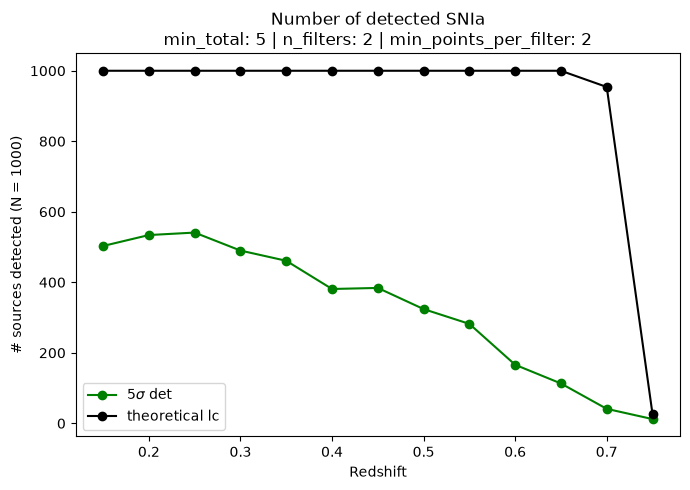

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(final_summary["z"],final_summary["n_detected"],marker="o", color = "g", label = '5$\sigma$ det')
ax.plot(final_summary["z"],final_summary["n_detected_theoretical"],marker="o", color = "k", label = 'theoretical lc')

ax.set_xlabel("Redshift")
ax.set_ylabel(f"# sources detected (N = {N_tot})")
ax.set_title(
    f"Number of detected SNIa\n"
    f"min_total: {selection_criteria['total_points']} | "
    f"n_filters: {selection_criteria['n_filters']} | "
    f"min_points_per_filter: {selection_criteria['min_points_per_filter']}"
)
plt.tight_layout()
plt.legend()
plt.show()

In [15]:
# this is still very important as a preliminary study to understand 

N_tot = 20
all_summaries = []

selection_criteria = set_selection_criteria(total_points=5,n_filters=2,min_points_per_filter=2)

for redshift in [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.65, 0.7]:

    snia_dict = generate_snia_dict(redshift=redshift,ra=None,dec=None,x1=0.0,t0=None,magabs=-19.323,c=0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)
    snia_models, data_models = generate_snia_lightcurve(
        *snia_param_list,
        bands=bands,
        in_mag=False,
        N_tot=N_tot,
        zp=30,
        tstart = tmin,
        tstop = tmax,
        plot_curve=False,
        return_values=True,
        return_models=True,
        verbose=False
    )

    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
    dset_target_indices = dset.data.index.get_level_values(0).unique().values
    # Test every target
    detected = []
    detected_theoretical = []

    for index in snia_models.data.index:

        if index in dset_target_indices:
            is_detected = five_sigma_detection_multiband(
                dataset=dset,
                targets=snia_models,
                index=index,
                selection_criteria=selection_criteria
            )
        else:
            is_detected = False

        detected.append(is_detected)

        theoretical = determine_visibility(data_models[index],return_dict=True,in_mag=False) #returns a dict

        # At least 2 theoretically visible bands
        is_detected_theoretical = (sum(theoretical.values()) >= 2)

        detected_theoretical.append(is_detected_theoretical)

    n_detected = sum(detected)
    n_detected_theoretical = sum(detected_theoretical)

    summary = {
        "z": redshift,
        "n_detected": n_detected,
        "fraction_detected": n_detected / N_tot,
        "n_detected_theoretical": n_detected_theoretical,
        "fraction_detected_theoretical": n_detected_theoretical / N_tot,
        "x1": snia_models.data["x1"].iloc[0],
        "c": snia_models.data["c"].iloc[0],
        "t0": snia_models.data["t0"].iloc[0],
        "magabs": snia_models.data["magabs"].iloc[0],
        "ra": snia_models.data["ra"].iloc[0],
        "dec": snia_models.data["dec"].iloc[0],
    }

    all_summaries.append(summary)

final_summary = pd.DataFrame(all_summaries)

print(final_summary)

NameError: name 'tmin' is not defined

In [82]:
final_summary

,z,n_detected,fraction_detected,n_detected_theoretical,fraction_detected_theoretical,x1,c,t0,magabs,ra,dec
0,0.15,627,0.3135,2000,1.0,0.0,0.0,61475.882812,-18.523001,332.118774,-46.894211
1,0.20,625,0.3125,2000,1.0,0.0,0.0,61475.882812,-18.523001,307.435730,9.964915
2,0.25,596,0.2980,2000,1.0,0.0,0.0,61475.882812,-18.523001,251.758942,-6.713835
3,0.30,491,0.2455,2000,1.0,0.0,0.0,61475.882812,-18.523001,125.483459,-43.296185
4,0.35,423,0.2115,2000,1.0,0.0,0.0,61475.882812,-18.523001,99.578003,-4.835781
5,0.40,297,0.1485,2000,1.0,0.0,0.0,61475.882812,-18.523001,5.222901,23.291655
6,0.45,189,0.0945,2000,1.0,0.0,0.0,61475.882812,-18.523001,80.345703,11.489657
7,0.50,95,0.0475,2000,1.0,0.0,0.0,61475.882812,-18.523001,170.727341,86.010643
8,0.60,4,0.0020,0,0.0,0.0,0.0,61475.882812,-18.523001,285.405243,28.424244
9,0.65,0,0.0000,0,0.0,0.0,0.0,61475.882812,-18.523001,129.845261,-44.878487


<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_17464/2509192069.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.plot(final_summary["z"],final_summary["n_detected"],marker="o", color = "g", label = '5 $\sigma$ det')


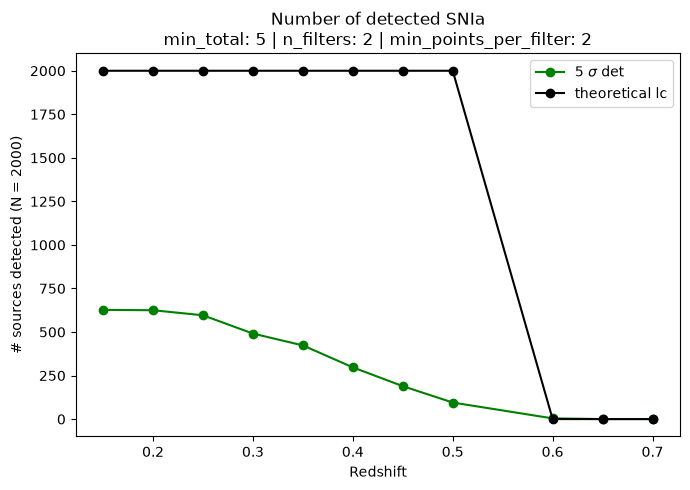

In [91]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(final_summary["z"],final_summary["n_detected"],marker="o", color = "g", label = '5 $\sigma$ det')
ax.plot(final_summary["z"],final_summary["n_detected_theoretical"],marker="o", color = "k", label = 'theoretical lc')

ax.set_xlabel("Redshift")
ax.set_ylabel(f"# sources detected (N = {N_tot})")
ax.set_title(
    f"Number of detected SNIa\n"
    f"min_total: {selection_criteria['total_points']} | "
    f"n_filters: {selection_criteria['n_filters']} | "
    f"min_points_per_filter: {selection_criteria['min_points_per_filter']}"
)
plt.tight_layout()
plt.legend()
plt.show()

(array([ 82., 111., 111., 103.,  91., 105., 104., 110., 102.,  99.,  82.,
         93.,  85., 108.,  99., 104.,  95., 122.,  99.,  95.]),
 array([61208.234375  , 61226.11328125, 61243.9921875 , 61261.875     ,
        61279.75390625, 61297.6328125 , 61315.51171875, 61333.390625  ,
        61351.2734375 , 61369.15234375, 61387.03125   , 61404.91015625,
        61422.7890625 , 61440.671875  , 61458.55078125, 61476.4296875 ,
        61494.30859375, 61512.1875    , 61530.0703125 , 61547.94921875,
        61565.828125  ]),
 <BarContainer object of 20 artists>)

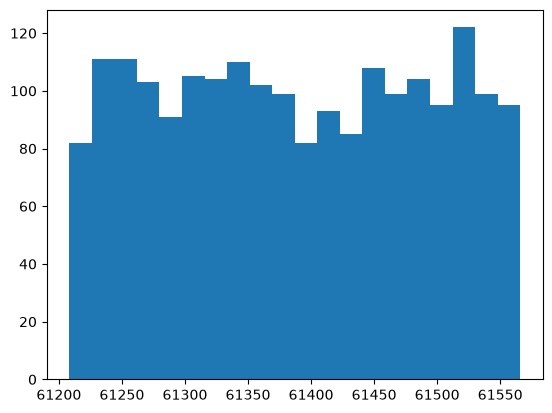

In [90]:
plt.hist(snia_models.data['t0'], bins = 20)

In [24]:
# for ONE index (i.e. index == 10)

result = compare_detection_conditions(dataset=dset,targets=snia_models,data_models=data_models,index=10)
result

# these are for MULTIPLE TARGETS WITH EVERY PARAM SAME.
# To do next: You still need to stack this (i.e. the values below each band column is the counts of detected SNIa)

# To do next (after 16 Aug 2026): For ONE target, focus on datapoint counts to see how many data points are visible

,condition,target,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,theoretical,10,0,1,1,1,1,1
1,5_sigma,10,0,0,0,0,0,0
2,five_sigma_multi,10,0,0,0,0,0,0


In [31]:
# stack all 1000 SNIa targets
all_results = []

for index in snia_models.data.index:
    result = compare_detection_conditions(dataset=dset,targets=snia_models,data_models=data_models,index=index)
    all_results.append(result)

all_results = pd.concat(all_results,ignore_index=True)

In [32]:
all_results[
    (all_results["condition"] == "5_sigma") &
    (all_results["lsstr"] == 1) # seen in that particular filter
].head()

,condition,target,lsstu,lsstg,lsstr,lssti,lsstz,lssty
1,5_sigma,0,0,0,1,1,1,1
6,5_sigma,1,0,0,1,1,0,1
11,5_sigma,2,0,0,1,1,1,1
16,5_sigma,3,0,0,1,1,0,1
21,5_sigma,4,0,0,1,1,0,1


In [33]:
all_results.groupby("condition")[lsst_bands].sum()

,lsstu,lsstg,lsstr,lssti,lsstz,lssty
condition,,,,,,
5_sigma,0,65,1000,1000,521,1000
5_sigma_flux_limit,0,65,1000,1000,119,173
five_sigma_multi,0,65,1000,1000,521,1000
flux_limit_multi,0,65,1000,1000,119,173
theoretical,1000,1000,1000,1000,1000,1000


In [34]:
summary = (all_results.groupby("condition")[lsst_bands].sum().reset_index())

In [35]:
summary

,condition,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,5_sigma,0,65,1000,1000,521,1000
1,5_sigma_flux_limit,0,65,1000,1000,119,173
2,five_sigma_multi,0,65,1000,1000,521,1000
3,flux_limit_multi,0,65,1000,1000,119,173
4,theoretical,1000,1000,1000,1000,1000,1000


#### plot avg. no of SOURCES DETECTED against redshift

If you want to display a target's params: <code>snia_models.data.loc[1].to_frame().T</code>

In [ ]:
N_tot = 500
all_summaries = []
# [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
for redshift in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:

    snia_dict = generate_snia_dict(redshift=redshift, ra=14.9, dec=-22.4, x1=0.0, t0=61250.0, magabs=-18.523,c=0.0)

    snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

    snia_models, data_models = generate_snia_lightcurve(*snia_param_list,bands=bands,in_mag=False,N_tot=N_tot,zp=30,plot_curve=False,return_values=True,return_models=True,verbose=False)

    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst,progress_bar=True,discard_bands=True)

    # Get detection results for every target
    target_results = []

    for index in snia_models.data.index:

        result = compare_detection_conditions(dataset=dset,targets=snia_models,data_models=data_models,index=index)

        target_results.append(result)

    target_results = pd.concat(target_results,ignore_index=True)

    # Sum detections over all targets
    summary = (target_results.groupby("condition")[lsst_bands].sum().reset_index())

    # Convert to average number of detections per target
    summary[lsst_bands]

    # Add redshift
    summary["z"] = redshift

    # Add the other fixed parameters
    for col in ["x1", "c", "t0", "magabs", "ra", "dec"]:
        summary[col] = snia_models.data[col].iloc[0]

    # Keep useful column order
    summary = summary[["condition", "z","x1","c","t0","magabs","ra","dec"] + lsst_bands]
    all_summaries.append(summary)

# Combine all redshifts
final_summary = pd.concat(all_summaries,ignore_index=True)

print(final_summary)

100%|██████████| 500/500 [00:05<00:00, 94.00it/s] 


          condition     z   x1    c       t0     magabs    ra   dec  lsstu  \
0           5_sigma  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4    500   
1  five_sigma_multi  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4    500   
2       theoretical  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4    500   

   lsstg  lsstr  lssti  lsstz  lssty  
0    500    500    500      0      0  
1    500    500    500      0      0  
2      0      0    500      0      0  


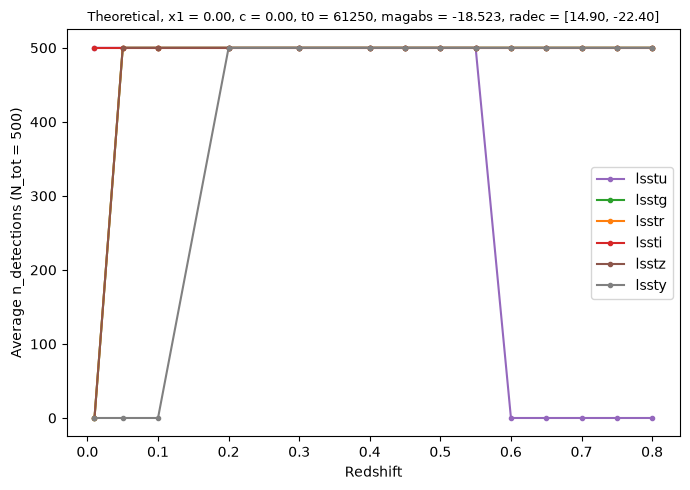

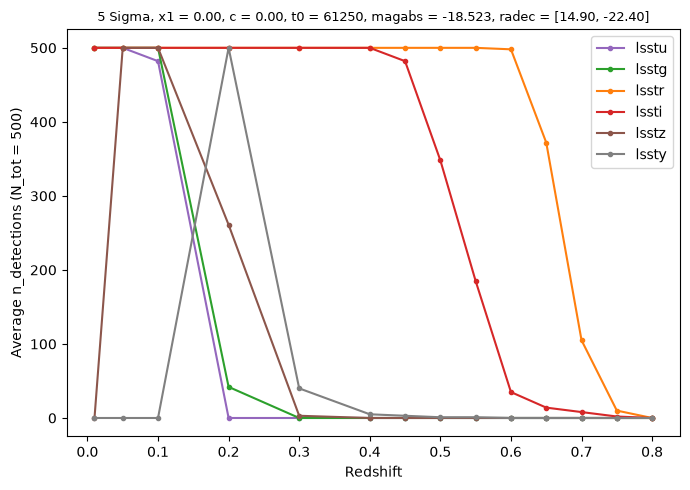

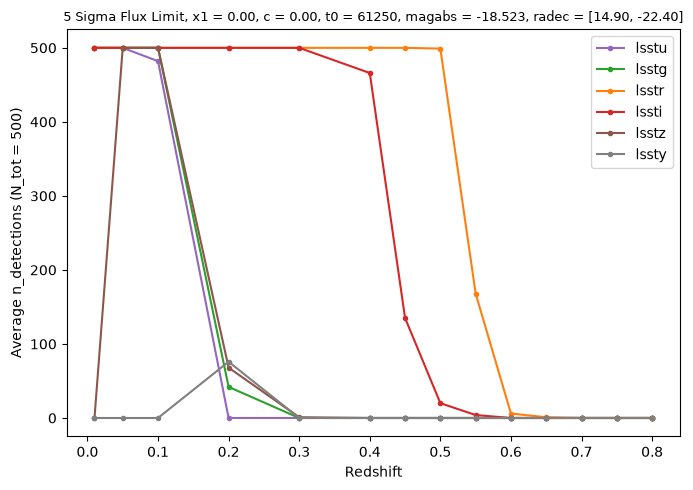

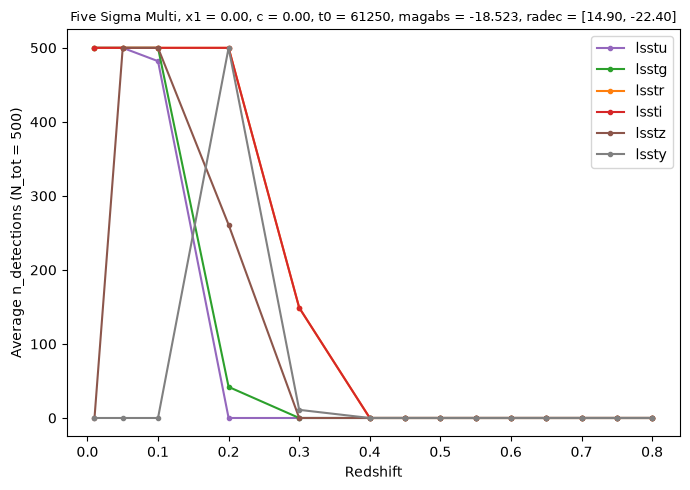

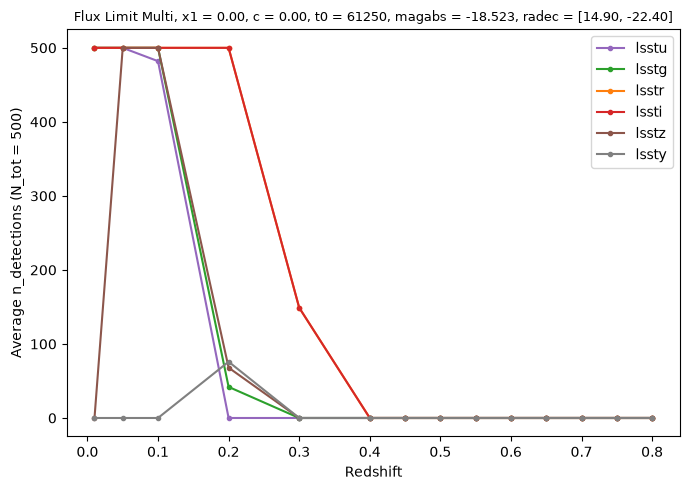

In [ ]:
for condition in ["theoretical", "5_sigma", "five_sigma_multi"]:

    fig, ax = plt.subplots(figsize=(7, 5))
    # subset: chose one criterion
    subset = final_summary[final_summary["condition"] == condition]
    x1 = subset["x1"].iloc[0]
    c = subset["c"].iloc[0]
    t0 = subset["t0"].iloc[0]
    magabs = subset["magabs"].iloc[0]
    ra = subset["ra"].iloc[0]
    dec = subset["dec"].iloc[0]

    for band in lsst_bands:
        ax.plot(subset["z"],subset[band],marker=".",label=band,color=limit_mag_dict[band]["color"])
        
    ax.set_xlabel("Redshift")
    ax.set_ylabel("Average n_detections (N_tot = {})".format(N_tot))
    ax.set_title(
        f"{condition.replace('_', ' ').title()}, "
        f"x1 = {x1:.2f}, c = {c:.2f}, "
        f"t0 = {t0:.0f}, magabs = {magabs:.3f}, "
        f"radec = [{ra:.2f}, {dec:.2f}]",
        fontsize=9,
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

#### Valid bands are only useful for the # sources detected section

In [4]:
from lightcurve import get_valid_bands, lsst_bands
valid_bands = get_valid_bands(model=snia_models.template.sncosmo_model, redshift=snia_models.data.loc[10, "z"], bands=lsst_bands)
valid_bands

NameError: name 'snia_models' is not defined

In [205]:
get_valid_bands(snia_models.template.sncosmo_model, redshift = snia_models.data.loc[10], bands = lsst_bands)
# dset.get_data(index = 10, detection = False) # will be the same for ALL indices (targets) since same params --> same theoretical LCs

['lsstg', 'lsstr', 'lssti', 'lsstz', 'lssty']

In [151]:
target = dset.data.loc[10]
target[target['band'].isin(['lsstg', 'lsstr', 'lsstu'])]

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr
index_obs,,,,,,,,
2770824,61261.406250,lsstr,24.485266,1,30,331967,133.759742,26.443373
2772648,61261.421875,lsstr,24.718338,1,30,331967,138.515773,26.657840
3332454,61269.425781,lsstr,48.146404,1,30,331967,87.245380,48.787638
3876993,61298.285156,lsstg,36.171204,1,30,331967,51.304449,36.205593
3880803,61298.304688,lsstr,33.454300,1,30,331967,-33.137521,33.609057
4038673,61301.277344,lsstr,47.049492,1,30,331967,-64.242119,47.148432
4707663,61318.281250,lsstg,24.247990,1,30,331967,18.905738,24.249050
4708517,61318.281250,lsstg,21.828072,1,30,331967,22.686462,21.829249
5936096,61345.054688,lsstg,20.342854,1,30,331967,-3.653009,20.342854


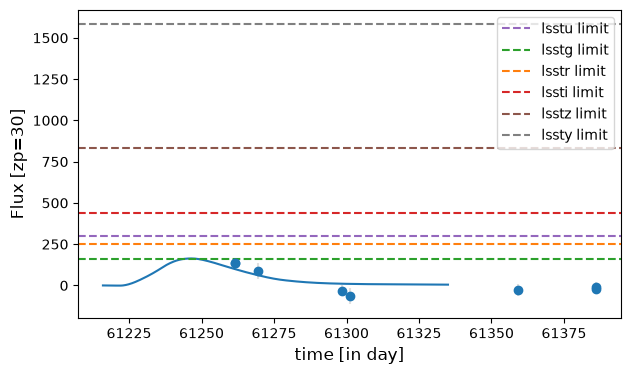

In [156]:
dset.show_target_lightcurve(index = 10, phase_window=[-60,200], zp = 30, bands = ['lsstr'], format_time = False)
# plt.xlim(61321, 61322)
ax = plt.gca()
for band in bands:
    ax.axhline(
        limit_mag_dict[band]["flux"],
        color=limit_mag_dict[band]["color"],
        linestyle="--",
        label=f"{band} limit",
    )
ax.legend()

In [110]:
# then, from the number of points, append it into n_detections
# (condition 2: with get_ndetections and condition 3: with get_ndetections AND filter limit)

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr,band_limitflux,SNR
index_obs,,,,,,,,,,
747982,61220.406250,lssty,187.444550,1,30,331967,431.861593,187.450856,1584.893,2.303866
884609,61222.398438,lssty,263.259705,1,30,331967,509.045209,263.270616,1584.893,1.933544
2493070,61249.316406,lssty,169.995941,1,30,331967,167.708086,170.624301,1584.893,0.982909
2770824,61261.406250,lsstr,24.485266,1,30,331967,133.759742,26.443373,251.189,5.058346
2772648,61261.421875,lsstr,24.718338,1,30,331967,138.515773,26.657840,251.189,5.196061
2860934,61262.421875,lssti,57.493050,1,30,331967,210.770241,58.940588,436.516,3.575978
3332454,61269.425781,lsstr,48.146404,1,30,331967,87.245380,48.787638,251.189,1.788268
3429213,61270.429688,lsstz,211.943130,1,30,331967,-119.422057,212.261963,831.764,-0.562616
3623916,61295.328125,lssti,76.185585,1,30,331967,75.774563,76.372389,436.516,0.992172


## Ok, now do for just one lightcurve

Note: we will use the average over 100 observations (due to random nature of noise + errors)
to establish the expected number of points detected.

In [ ]:
from skysurvey.tools.utils import get_skynoise_from_maglimit
get_skynoise_from_maglimit()

In [ ]:
# snia_dict = generate_snia_dict(redshift = 0.2, ra = 14.9, dec = -22.4, x1 = 0.0, t0 = 61250.0, magabs = -18.523, c = 0.0)

In [4]:
tmin, tmax = lsst.date_range

In [5]:
snia_dict = generate_snia_dict(redshift = None, ra = None, dec = None, x1 = None, t0 = None, magabs = None, c = None)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = False, N_tot = 10, zp=30, tstart= tmin - 100, tstop = tmax, plot_curve = False, return_values = True, return_models = True, verbose = False)

All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x7814d5c4f480>, 'kwargs': {'N': 10, 'R_z': <function R_SFR at 0x7814d5853cc0>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x7814d8b60880>, 'kwargs': {'dec_range': [-90, 0]}}}


In [6]:
snia_models.data

,z,x1,c,t0,ra,dec,magabs,magobs,template
0,0.798868,0.795,0.002,61442.371094,193.892395,-7.536946,-19.484398,24.075994,salt2
1,0.802838,0.265,-0.094,61163.125000,213.619263,-16.054398,-19.807529,23.766054,salt2
2,0.041346,-1.175,-0.092,61428.265625,90.875214,-3.816494,-19.267357,17.114025,salt2
3,0.910638,0.370,0.003,61180.699219,277.135284,-22.025949,-19.240318,24.669218,salt2
4,0.814667,0.525,0.128,61231.691406,178.523148,-41.318062,-19.011110,24.601412,salt2
5,0.812047,-0.160,0.133,61191.140625,305.115143,-17.288937,-19.011181,24.592764,salt2
6,0.967363,-1.620,0.072,61402.121094,109.845627,-37.065189,-18.777107,25.293907,salt2
7,0.983321,0.810,0.103,61225.746094,231.129471,-13.270518,-19.200989,24.913778,salt2
8,0.600296,0.155,-0.054,61528.734375,270.553101,-27.539110,-19.549982,23.254362,salt2
9,0.435691,0.665,0.399,61495.796875,40.842339,-35.400257,-18.050325,23.920319,salt2


In [144]:
lsst.data.columns.to_list()

['skynoise',
 'mjd',
 'band',
 'gain',
 'zp',
 'ra',
 'dec',
 'observationId',
 'fieldid_survey',
 'fieldid']

In [ ]:
def flux_to_mag(flux, zp=30):
    return zp - 2.5*np.log10(flux)

def mag_to_flux(mag, zp=30):
    return 10**(-0.4*(mag-zp))

def flux_5sigma_from_skynoise(skynoise):
    flux_5sigma = (25 + np.sqrt((25)**2. + 100 * skynoise**2)) / 2
    return flux_5sigma

def m5_from_skynoise(skynoise, zp=30):
    flux_5sigma = flux_5sigma_from_skynoise(skynoise)
    return flux_to_mag(flux_5sigma, zp=zp)

In [98]:
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)

100%|██████████| 6731/6731 [00:51<00:00, 131.76it/s]


In [101]:
dset.data

mjd   band    skynoise  gain  zp  fieldid  \
index index_obs                                                       
3     814061     61221.191406  lssty  235.813644     1  30   337859   
      2370218    61248.105469  lsstz  135.770889     1  30   337859   
      2375510    61248.128906  lssty  356.439911     1  30   337859   
      2440134    61249.093750  lssty  280.255646     1  30   337859   
      2444654    61249.113281  lssty  236.154114     1  30   337859   
...                       ...    ...         ...   ...  ..      ...   
9998  13350175   61478.085938  lsstz   73.499008     1  30   290984   
      13354292   61478.101562  lssti   45.805332     1  30   290984   
      13919126   61486.027344  lsstz   86.331116     1  30   290984   
      13923386   61486.046875  lssti   88.889839     1  30   290984   
      15932149   61512.003906  lssti  101.245735     1  30   290984   

                       flux     fluxerr  
index index_obs                          
3     814061    -377.105098  235.813950  
      2370218    -50.805067  135.772316  
      2375510   -166.340001  356.440209  
      2440134     13.301318  280.255996  
      2444654   -185.328006  236.154530  
...                     ...         ...  
9998  13350175  -189.507900   73.499007  
      13354292    19.430658   45.805332  
      13919126   -80.455254   86.331116  
      13923386    86.531055   88.889838  
      15932149   -17.344662  101.245737  

[121515 rows x 8 columns]

In [ ]:
from lightcurve import lsst_bands
from lsst_functions import get_number_detections_allbands, five_sigma_detection_multiband

N_tot = 10000

snia_dict = generate_snia_dict(redshift = None, ra = None, dec = None, x1 = None, t0 = None, magabs = None, c = None)
print(snia_dict)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
print(snia_param_list)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = False, N_tot = N_tot, zp=30, tstart= tmin - 100, tstop = tmax, plot_curve = False, return_values = True, return_models = True, verbose = False)
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
dset_target_indices = dset.data.index.get_level_values(0).unique().values
print('dset target idx', dset_target_indices)
# Test every target
detected = []

for index in snia_models.data.index:
    total_detection_points = 0
    is_detected = False

    if index in dset_target_indices:
        is_detected = five_sigma_detection_multiband(dataset=dset,targets=snia_models,index=index,selection_criteria=selection_criteria)
    else:
        is_detected = False
        total_detection_points = 0

    if is_detected:
        total_detection_points = get_number_detections_allbands(dataset=dset,targets=snia_models,index=index,selection_criteria=selection_criteria)

    detected.append({
        "target": index,
        "z": snia_models.data.loc[index, "z"],
        "ra": snia_models.data.loc[index, "ra"],
        "dec": snia_models.data.loc[index, "dec"],
        "t0": snia_models.data.loc[index, "t0"],
        "detected": is_detected,
        "n_detections": total_detection_points,

    })
detected = pd.DataFrame(detected)

detected.to_parquet(
    "test_parquet.parquet",
    engine="pyarrow",
    compression="zstd",
    index=False
)

{}
[None, None, None, None, None, None, None]
All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x7cbcb65e0f60>, 'kwargs': {'N': 10000, 'R_z': <function R_SFR at 0x7cbcb64dd0c0>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x7cbcb9f14a90>, 'kwargs': {'dec_range': [-90, 0]}}}


100%|██████████| 9998/9998 [01:01<00:00, 161.87it/s] 


dset target idx [   0    1    2 ... 9997 9998 9999]


,target,z,ra,dec,t0,detected,n_detections,z_bin
0,0,0.391595,137.598007,-27.899683,61451.925781,True,16,"[0.38, 0.4)"
1,1,0.628783,291.860168,-0.813505,61426.632812,False,0,"[0.62, 0.64)"
2,2,0.573308,248.084091,-81.774208,61449.066406,False,0,"[0.56, 0.58)"
3,3,0.285084,271.158142,-14.354739,61192.343750,True,7,"[0.28, 0.3)"
4,4,0.692918,328.366333,-1.830170,61162.875000,False,0,"[0.68, 0.7)"
...,...,...,...,...,...,...,...,...
9995,9995,0.196232,84.348785,-15.727390,61270.667969,False,0,"[0.18, 0.2)"
9996,9996,0.205392,172.949387,-51.370121,61555.171875,False,0,"[0.2, 0.22)"
9997,9997,0.614645,15.414575,-45.277348,61403.656250,False,0,"[0.6, 0.62)"
9998,9998,0.994361,224.058289,-9.600336,61220.714844,False,0,"[0.98, 1.0)"


In [ ]:
dets = dset.get_data(detection = None)
for band in lsst_bands:
    print(f'band {band}: {(dets['band'] == band).sum()}')

band lsstu: 18260
band lsstg: 51737
band lsstr: 82240
band lssti: 74844
band lsstz: 78302
band lssty: 58222


In [27]:
dets

mjd   band    skynoise  gain  zp  fieldid  \
index index_obs                                                       
0     8677971    61398.242188  lssty  247.423126     1  30   351694   
      8682003    61398.261719  lsstz  100.640907     1  30   351694   
      8943585    61404.359375  lsstz   94.903763     1  30   351694   
      8992034    61405.359375  lsstr   35.564835     1  30   351694   
      9047422    61406.347656  lssty  168.244049     1  30   351694   
...                       ...    ...         ...   ...  ..      ...   
9998  19145417   61565.968750  lsstr   56.589104     1  30   280302   
9999  7103149    61367.238281  lsstz  128.514771     1  30   315750   
      7473651    61374.238281  lsstz   89.881996     1  30   315750   
      7569165    61376.253906  lsstr   39.064293     1  30   315750   
      7574572    61376.273438  lsstr   31.946062     1  30   315750   

                       flux     fluxerr  
index index_obs                          
0     8677971   -115.286789  247.423126  
      8682003   -116.638843  100.640905  
      8943585    -11.365016   94.903765  
      8992034     41.076477   35.564834  
      9047422   -230.258765  168.244051  
...                     ...         ...  
9998  19145417   -73.815313   56.589104  
9999  7103149    -31.128233  128.514773  
      7473651     90.832397   89.881997  
      7569165     -1.675140   39.064292  
      7574572    -36.339930   31.946062  

[363605 rows x 8 columns]

In [28]:
snia_models.data

,z,x1,c,t0,ra,dec,magabs,magobs,template
0,0.391595,-0.320,-0.028,61451.925781,137.598007,-27.899683,-19.264111,22.433046,salt2
1,0.628783,1.420,-0.059,61426.632812,291.860168,-0.813505,-19.600019,23.326294,salt2
2,0.573308,0.690,0.030,61449.066406,248.084091,-81.774208,-19.295753,23.387896,salt2
3,0.285084,-0.295,-0.063,61192.343750,271.158142,-14.354739,-19.469633,21.427156,salt2
4,0.692918,-0.535,0.091,61162.875000,328.366333,-1.830170,-19.068083,24.114666,salt2
...,...,...,...,...,...,...,...,...,...
9995,0.196232,0.915,-0.067,61270.667969,84.348785,-15.727390,-19.517792,20.462719,salt2
9996,0.205392,-0.650,0.088,61555.171875,172.949387,-51.370121,-18.935659,21.155354,salt2
9997,0.614645,-0.105,-0.068,61403.656250,15.414575,-45.277348,-19.332764,23.533684,salt2
9998,0.994361,-1.950,0.010,61220.714844,224.058289,-9.600336,-18.910494,25.234133,salt2


In [55]:
detected_indices = detected[detected['detected'] == True].index

In [84]:
detected.loc[detected_indices]

,target,z,ra,dec,t0,detected,n_detections,z_bin
0,0,0.391595,137.598007,-27.899683,61451.925781,True,16,"[0.38, 0.4)"
3,3,0.285084,271.158142,-14.354739,61192.343750,True,7,"[0.28, 0.3)"
13,13,0.223640,317.107025,-68.060127,61216.707031,True,27,"[0.22, 0.24)"
16,16,0.026068,82.119576,-45.407341,61442.429688,True,12,"[0.02, 0.04)"
19,19,0.061185,281.459473,-68.343460,61301.980469,True,7,"[0.06, 0.08)"
...,...,...,...,...,...,...,...,...
9956,9956,0.314422,294.147430,-19.324717,61269.667969,True,13,"[0.3, 0.32)"
9966,9966,0.155386,331.392609,-80.590652,61260.292969,True,7,"[0.14, 0.16)"
9970,9970,0.107420,24.552122,-61.934704,61386.097656,True,8,"[0.1, 0.12)"
9983,9983,0.550160,68.093513,-5.037573,61345.363281,True,15,"[0.54, 0.56)"


In [32]:
z_bins = np.arange(0, 1.01, 0.02)
detected["z_bin"] = pd.cut(detected["z"],bins=z_bins,right=False)
n_sources = (detected[detected["detected"]].groupby("z_bin", observed=True).size())
n_points = (detected[detected["detected"]].groupby("z_bin", observed=True)["n_detections"].sum())

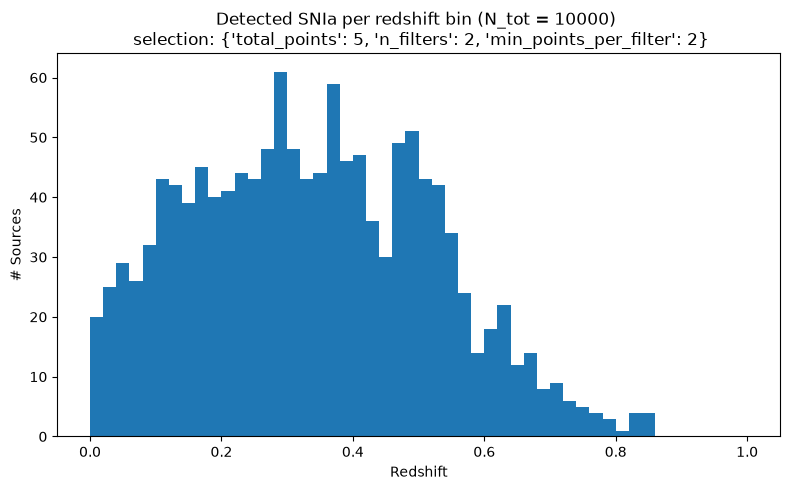

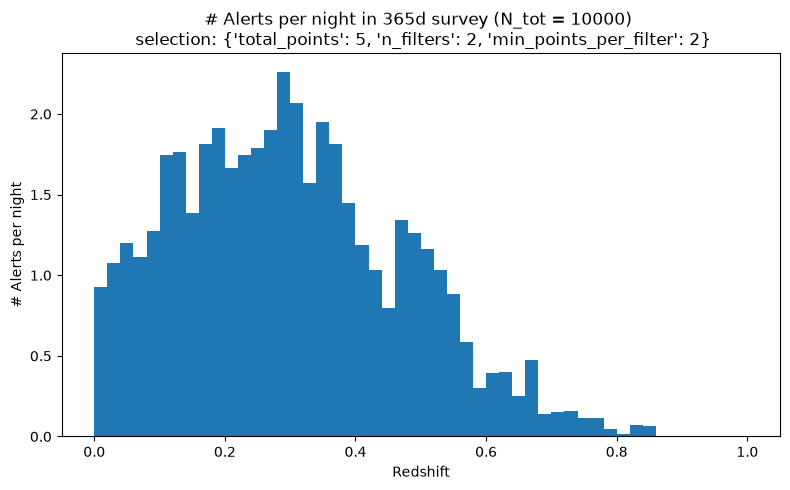

In [ ]:
detected_sources = detected[detected["detected"]]

plt.figure(figsize=(8, 5))

plt.hist(detected_sources["z"],bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title(f"Detected SNIa per redshift bin (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(detected_sources['z'], weights = detected_sources["n_detections"]/365, bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title(f"# Alerts per night in 365d survey (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

In [63]:
detected_indices = detected.loc[detected["detected"], "target"]
print(detected_indices)
detected_models = snia_models.data.loc[detected_indices]
detected_models

0          0
3          3
13        13
16        16
19        19
        ... 
9956    9956
9966    9966
9970    9970
9983    9983
9989    9989
Name: target, Length: 1298, dtype: int64


,z,x1,c,t0,ra,dec,magabs,magobs,template
0,0.391595,-0.320,-0.028,61451.925781,137.598007,-27.899683,-19.264111,22.433046,salt2
3,0.285084,-0.295,-0.063,61192.343750,271.158142,-14.354739,-19.469633,21.427156,salt2
13,0.223640,0.990,-0.064,61216.707031,317.107025,-68.060127,-19.786240,20.511986,salt2
16,0.026068,-0.550,-0.092,61442.429688,82.119576,-45.407341,-19.550402,15.805115,salt2
19,0.061185,1.005,0.125,61301.980469,281.459473,-68.343460,-18.919134,18.343885,salt2
...,...,...,...,...,...,...,...,...,...
9956,0.314422,-0.745,-0.081,61269.667969,294.147430,-19.324717,-19.520199,21.621410,salt2
9966,0.155386,-1.580,0.078,61260.292969,331.392609,-80.590652,-18.821167,20.599728,salt2
9970,0.107420,0.695,0.060,61386.097656,24.552122,-61.934704,-19.210442,19.342831,salt2
9983,0.550160,0.355,-0.112,61345.363281,68.093513,-5.037573,-19.708424,22.867357,salt2


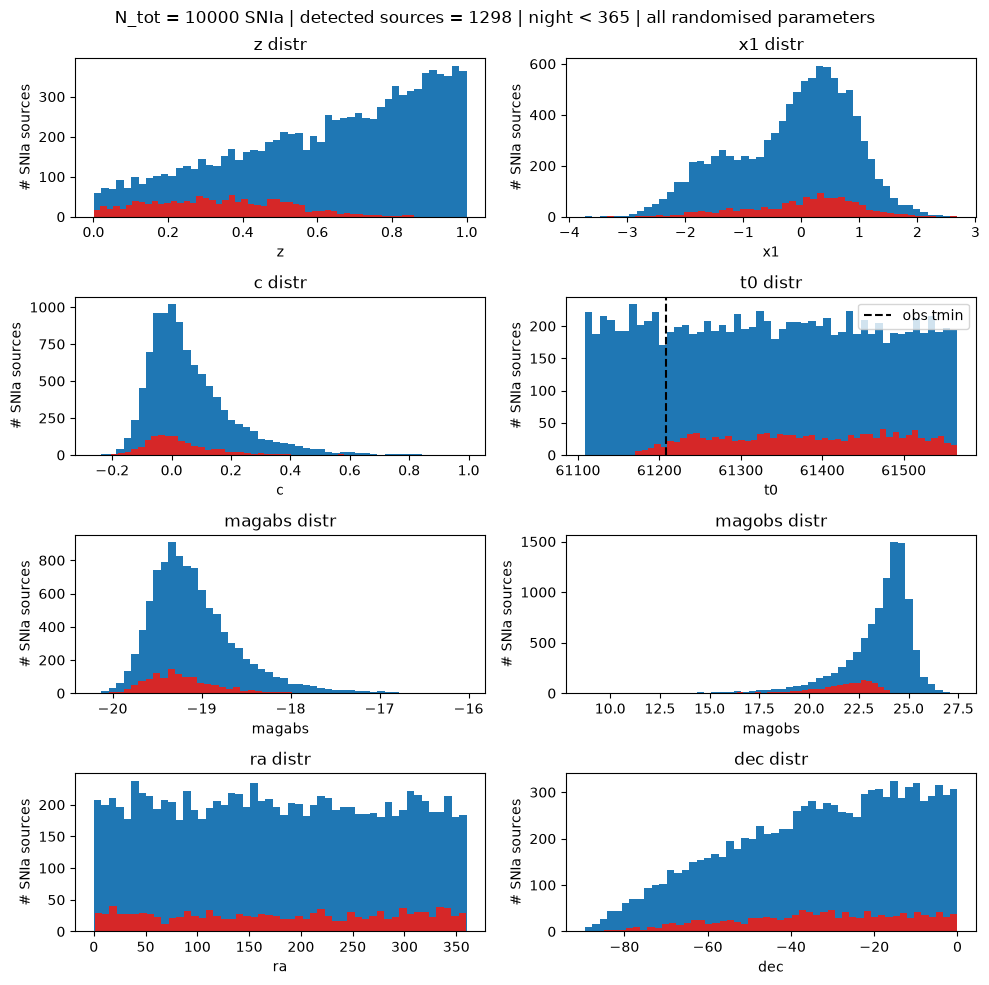

In [ ]:
# now plot for each param:
    # to write in the train. overplot histogram with detections?

print()

params = ['z', 'x1', 'c', 't0', 'magabs', 'magobs', 'ra', 'dec']

fig, axs = plt.subplots(4, 2, figsize=(10, 10))

for ax, param in zip(axs.flat, params):
    ax.hist(snia_models.data[param], bins=50, color = 'tab:blue') #axes.hist --> use counts, bins = ...
    ax.hist(detected_models[param], bins=50, color = 'tab:red')
    if param == 't0':
        ax.axvline(tmin, color = 'k', linestyle = '--', label = 'obs tmin')
        ax.legend()
    ax.set_xlabel(param)
    ax.set_ylabel("# SNIa sources")
    ax.set_title(f"{param} distr")

# Hide unused subplot
for ax in axs.flat[len(params):]:
    ax.set_visible(False)
plt.suptitle(f'N_tot = {N_tot} SNIa | detected sources = {len(detected_models)} | night < 365 | all randomised parameters')
plt.tight_layout()

plt.show()

#interesting: percentage wise, at each redshift bin, how many we can transients.
# colour band might still be useful --> each own histograms
# get this one for all sources in 1 year first later 
# clean up and put into file. put into README.

In [ ]:
pd.read_parquet('test_parquet.parquet')

,target,z,ra,dec,t0,detected,n_detections
0,0,0.391595,137.598007,-27.899683,61451.925781,True,16
1,1,0.628783,291.860168,-0.813505,61426.632812,False,0
2,2,0.573308,248.084091,-81.774208,61449.066406,False,0
3,3,0.285084,271.158142,-14.354739,61192.343750,True,7
4,4,0.692918,328.366333,-1.830170,61162.875000,False,0
...,...,...,...,...,...,...,...
9995,9995,0.196232,84.348785,-15.727390,61270.667969,False,0
9996,9996,0.205392,172.949387,-51.370121,61555.171875,False,0
9997,9997,0.614645,15.414575,-45.277348,61403.656250,False,0
9998,9998,0.994361,224.058289,-9.600336,61220.714844,False,0


In [15]:
z_bins = np.arange(0, 1.01, 0.05)
detected["z_bin"] = pd.cut(detected["z"],bins=z_bins,right=False)
n_sources = (detected[detected["detected"]].groupby("z_bin", observed=True).size())
n_points = (detected[detected["detected"]].groupby("z_bin", observed=True)["n_detections"].sum())

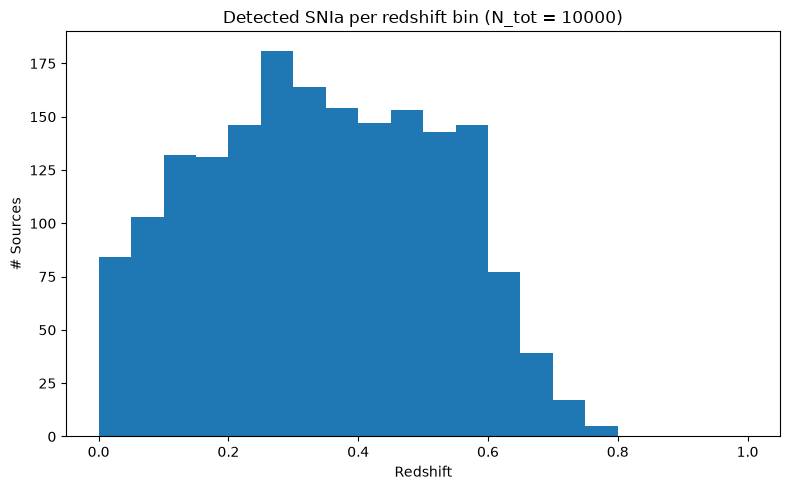

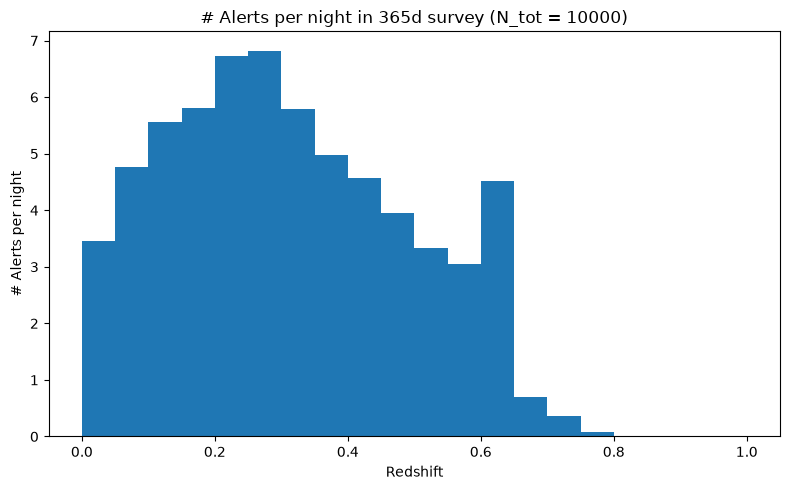

In [50]:
detected_sources = detected[detected["detected"]]

z_bins = np.arange(0, 1.01, 0.05)

plt.figure(figsize=(8, 5))

plt.hist(detected_sources["z"],bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title("Detected SNIa per redshift bin (N_tot = 10000)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(detected_sources['z'], weights = detected_sources["n_detections"]/365, bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title("# Alerts per night in 365d survey (N_tot = 10000)")

plt.tight_layout()
plt.show()

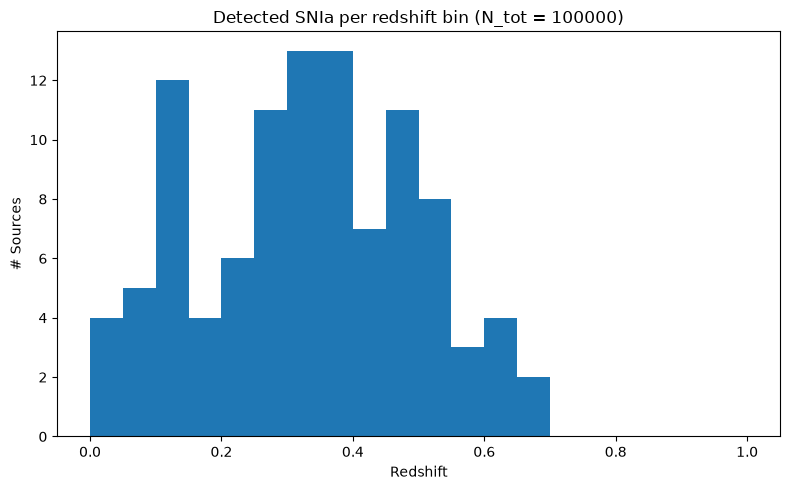

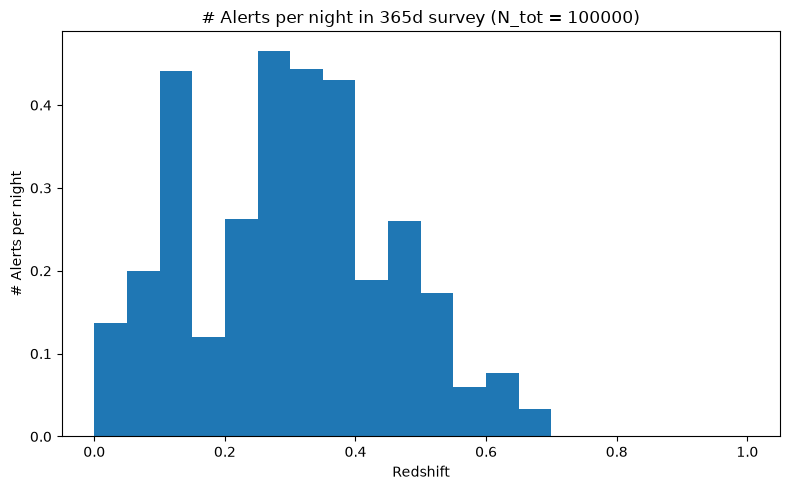

In [18]:
detected_sources = detected[detected["detected"]]

z_bins = np.arange(0, 1.01, 0.05)

plt.figure(figsize=(8, 5))

plt.hist(detected_sources["z"],bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title("Detected SNIa per redshift bin (N_tot = 100000)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(detected_sources['z'], weights = detected_sources["n_detections"]/365, bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title("# Alerts per night in 365d survey (N_tot = 100000)")

plt.tight_layout()
plt.show()

(array([47., 39., 60., 67., 85., 84., 65., 78., 37., 23., 11.,  6.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

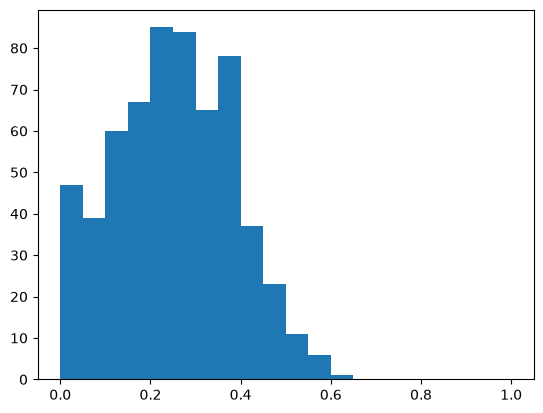

In [154]:
true_detection = detected[detected['detected'] == True]
plt.hist(true_detection['z'], bins = z_bins)

In [ ]:
detected_sources = detected[detected["detected"]].copy()

detected_sources["z_bin"] = pd.cut( detected_sources["z"],bins=z_bins,right=False)

for z_bin, group in detected_sources.groupby("z_bin", observed=True):

    plt.figure(figsize=(7, 5))

    plt.hist(group["n_detections"],bins=30,)

    plt.xlabel("Number of 5σ detections")
    plt.ylabel("Number of SNe Ia")
    plt.title(f"n_detections distribution, z = {z_bin}")

    plt.tight_layout()
    plt.show()

(array([ 6.,  6., 11.,  2.,  4.,  7., 12.,  4.,  6.,  3.]),
 array([0.00297999, 0.05352387, 0.10406774, 0.15461162, 0.20515549,
        0.25569937, 0.30624324, 0.35678712, 0.40733099, 0.45787486,
        0.50841874]),
 <BarContainer object of 10 artists>)

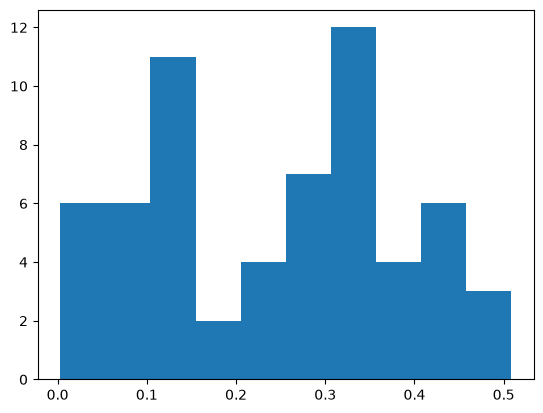

In [ ]:
# detected['detected'] FOR 10000
true_detection = detected[detected['detected'] == True]
plt.hist(true_detection['z'], bins = z_bins)

In [ ]:
# add this to the loop; where you append the count to whichever bin. but i want to just do it separately..
snia_models.data['z']
bin_edges = np.arange(0, 10, 0.5) #redshift bins

,z,x1,c,t0,magabs,ra,dec,magobs,template
0,0.674578,0.0,0.0,61395.660156,-18.523001,298.759583,42.582870,24.588808,salt2
1,2.178975,0.0,0.0,61139.242188,-18.523001,3.306056,62.305096,27.714092,salt2
2,3.456411,0.0,0.0,61410.855469,-18.523001,345.032410,4.573329,28.921059,salt2
3,2.764333,0.0,0.0,61134.250000,-18.523001,243.100876,-23.971828,28.339607,salt2
4,1.877935,0.0,0.0,61299.753906,-18.523001,101.848244,20.521761,27.320293,salt2
...,...,...,...,...,...,...,...,...,...
9995,1.940255,0.0,0.0,61377.667969,-18.523001,64.217186,12.990143,27.406935,salt2
9996,1.418016,0.0,0.0,61514.910156,-18.523001,155.887970,30.931643,26.571537,salt2
9997,3.089532,0.0,0.0,61220.808594,-18.523001,80.022705,-4.629077,28.629787,salt2
9998,1.235217,0.0,0.0,61331.957031,-18.523001,96.899948,-12.269678,26.202257,salt2


In [40]:
detection = dset.get_ndetection(per_band = True, join_bandday = False)
detection

index  band 
147    lssti    1
162    lsstg    2
       lssti    2
       lsstr    2
180    lsstg    2
               ..
9755   lsstg    4
       lssti    7
       lsstr    7
       lsstu    2
       lsstz    8
Length: 279, dtype: int64

In [45]:
detection_list = dset.get_data(index = 147, detection = True)
detection_list

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr
index_obs,,,,,,,,
11680719,61454.171875,lssti,89.418297,1,30,458208,468.708911,90.514995


In [49]:
snia_models.data.iloc[147]

z               0.728018
x1                   0.0
c                    0.0
t0          61461.007812
magabs        -18.523001
ra            137.852386
dec           -65.598839
magobs         24.790661
template           salt2
Name: 147, dtype: object

In [54]:
dset_target_indices = dset.data.index.get_level_values(0).unique().values #because many get discarded from valid_bands
dset_target_indices

array([   0,    2,    4, ..., 9996, 9997, 9999], shape=(4811,))

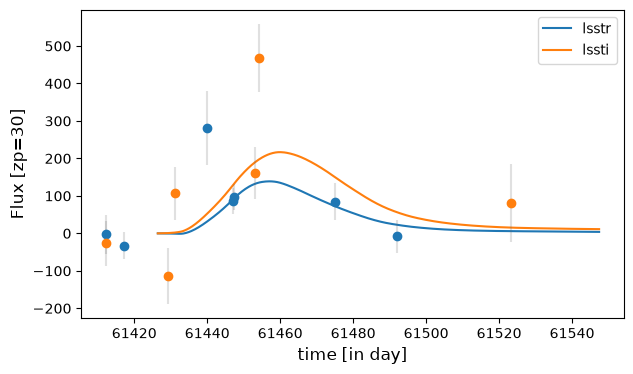

In [46]:
fig = dset.show_target_lightcurve(index = 147, phase_window=[-60,250], zp = 30, bands = ['lsstr', 'lssti'], format_time = False)
ax = fig.axes[0]
ax.legend(["lsstr", "lssti"])

In [ ]:
def get_indices_from_detection_list(dset):
    """
    get target indices with detections
    Input:
        - dset (skysurvey.dataset.DataSet instance): after skysurvey.DataSet.from_targets_and_survey(...)
    Output:
        - indices_in_bandpass (ndArray): List of indices where the transient spectra still lies within at least one LSST band after cosmo redshift.
    """
    indices_in_bandpass = dset.data.index.get_level_values(0).unique().values
    return indices_in_bandpass

In [57]:
get_indices_from_detection_list(dset)

array([   0,    2,    4, ..., 9996, 9997, 9999], shape=(4811,))

In [58]:
detection[:, 'lsstr'] #or detection.xs("lsstr", level="band")

index
162     2
180     4
187     6
194     1
304     5
       ..
9545    3
9635    1
9746    2
9749    1
9755    7
Length: 96, dtype: int64

In [ ]:
dset.show_target_lightcurve(index = 6, phase_window=[-60,200], zp = 30, zpsys = 'ab', bands = ['lsstg'], format_time = False)

In [ ]:
detections = dset.get_data(index = None, detection=None)

In [95]:
test_row = detections[detections['band'] == 'lssty']
test_row#.iloc[0:70] #iloc gives first row, .loc[0] gives all within SNIa index 0 

mjd   band    skynoise  gain  zp  fieldid  \
index index_obs                                                       
8     2630016    61252.285156  lssty  223.342697     1  30   419522   
15    2600229    61251.402344  lssty  183.503677     1  30   402273   
18    2445875    61249.117188  lssty  212.857635     1  30   397872   
23    2495362    61249.324219  lssty  198.940598     1  30   338361   
26    2316304    61247.195312  lssty  272.655670     1  30   447299   
...                       ...    ...         ...   ...  ..      ...   
991   2234055    61246.304688  lssty  277.609558     1  30   342390   
993   2212320    61246.214844  lssty  267.458008     1  30   322451   
      2215742    61246.230469  lssty  248.077103     1  30   322451   
      2215973    61246.230469  lssty  230.861282     1  30   322451   
994   2444631    61249.109375  lssty  236.273026     1  30   337852   

                        flux     fluxerr  
index index_obs                           
8     2630016    1481.206573  226.221268  
15    2600229    1239.169292  187.094493  
18    2445875    1529.135390  216.180428  
23    2495362    1289.195598  202.473958  
26    2316304    1764.520167  275.309374  
...                      ...         ...  
991   2234055    1491.647984  280.202911  
993   2212320    1415.302173  270.146303  
      2215742    1775.402497  250.973565  
      2215973    1263.042591  233.970968  
994   2444631    1341.752598  239.271408  

[289 rows x 8 columns]

In [21]:
mags = []
mags_darksky = []
for r in range(len(test_row)):
    test = test_row.iloc[r]
    skynoise = test['skynoise']
    flux = test['flux']
    gain = 1
    fluxerr = np.sqrt(skynoise ** 2 + np.abs(flux / gain))
    flux_at_5sig = fluxerr * 5
    flux_at_5sig_darksky = skynoise * 5
    limit_mag = flux_to_mag(flux_at_5sig, zp = 30)
    limit_mag_darksky = flux_to_mag(flux_at_5sig_darksky, zp = 30)
    mags.append(limit_mag)
    mags_darksky.append(limit_mag_darksky)

In [22]:
np.median(mags), np.median(mags_darksky)

(np.float64(22.438805529053802), np.float32(22.4432))

In [119]:
limit_mag_dict = {'lsstu': {'mag': 23.8, 'flux': 301.995, 'color': 'tab:purple'},
            'lsstg': {'mag': 24.5, 'flux': 158.489, 'color': 'tab:green'},
            'lsstr': {'mag': 24.0, 'flux': 251.189, 'color': 'tab:orange'},
            'lssti': {'mag': 23.4, 'flux': 436.516, 'color': 'tab:red'},
            'lsstz': {'mag': 22.7, 'flux': 831.764, 'color': 'tab:brown'},
            'lssty': {'mag': 22.0, 'flux': 1584.893, 'color': '0.5'}}

dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=False)
dataset = dset.get_data(index = None, detection=None)

100%|██████████| 1000/1000 [00:06<00:00, 157.35it/s]


In [113]:
dataset

mjd   band    skynoise  gain  zp  fieldid  \
index index_obs                                                       
0     759571     61220.960938  lsstr   80.586960     1  30   265212   
      10026793   61427.316406  lssty  260.933319     1  30   265212   
      10103502   61428.332031  lssty  201.597168     1  30   265212   
      10104755   61428.335938  lssty  195.861954     1  30   265212   
      10109024   61428.355469  lssty  192.678558     1  30   265212   
...                       ...    ...         ...   ...  ..      ...   
999   12250448   61463.378906  lsstz  123.843010     1  30   173961   
      12717221   61469.300781  lsstu   85.431694     1  30   173961   
      13228851   61476.234375  lsstg   27.710024     1  30   173961   
      13231530   61476.246094  lsstg   27.030094     1  30   173961   
      14198400   61489.246094  lssty  285.999878     1  30   173961   

                       flux     fluxerr  
index index_obs                          
0     759571    -111.728014   80.586961  
      10026793   198.335348  260.933316  
      10103502  -368.040813  201.597168  
      10104755   354.280382  195.861957  
      10109024    61.941630  192.678560  
...                     ...         ...  
999   12250448    66.316112  123.843009  
      12717221    -6.177285   85.431693  
      13228851   -26.972581   27.710023  
      13231530   -34.414835   27.030094  
      14198400   643.535170  285.999877  

[27888 rows x 8 columns]

In [100]:
snia_models.data

,z,x1,c,t0,magabs,ra,dec,magobs,template
0,0.674578,0.0,0.0,61395.660156,-18.523001,298.759583,42.582870,24.588808,salt2
1,2.178975,0.0,0.0,61139.242188,-18.523001,3.306056,62.305096,27.714092,salt2
2,3.456411,0.0,0.0,61410.855469,-18.523001,345.032410,4.573329,28.921059,salt2
3,2.764333,0.0,0.0,61134.250000,-18.523001,243.100876,-23.971828,28.339607,salt2
4,1.877935,0.0,0.0,61299.753906,-18.523001,101.848244,20.521761,27.320293,salt2
...,...,...,...,...,...,...,...,...,...
9995,1.940255,0.0,0.0,61377.667969,-18.523001,64.217186,12.990143,27.406935,salt2
9996,1.418016,0.0,0.0,61514.910156,-18.523001,155.887970,30.931643,26.571537,salt2
9997,3.089532,0.0,0.0,61220.808594,-18.523001,80.022705,-4.629077,28.629787,salt2
9998,1.235217,0.0,0.0,61331.957031,-18.523001,96.899948,-12.269678,26.202257,salt2


In [120]:
#Fixed LC params, 1000 copies
from lightcurve import lsst_bands
m5 = {'lsstu': 23.70, 'lsstg': 24.97, 'lsstr': 24.52, 'lssti': 24.13, 'lsstz': 23.56, 'lssty': 22.55}
m5_new = {'lsstu': 23.80, 'lsstg': 24.50, 'lsstr': 24.00, 'lssti': 23.4, 'lsstz': 22.70, 'lssty': 22.0}

mean_mag = {}
mean_mag_darksky = {}
median_mag = {}
median_mag_darksky = {}

for band in lsst_bands:
    band_data = dataset[dataset["band"] == band]
    # print(len(band_data))
    m5_values = flux_to_mag(5 * np.sqrt(band_data["skynoise"] ** 2 + np.abs(band_data['flux'])), zp=30)
    m5_dark_values = flux_to_mag(5 * band_data["skynoise"], zp=30)
    mean_mag[band] = np.mean(m5_values)
    mean_mag_darksky[band] = np.mean(m5_dark_values)
    median_mag[band] = np.median(m5_values)
    median_mag_darksky[band] = np.median(m5_dark_values)

combined_mag_estimates_fixedpos = pd.DataFrame({
    "mean_mag": mean_mag,
    "mean_mag_darksky": mean_mag_darksky,
    "median_mag": median_mag,
    "median_mag_darksky": median_mag_darksky,
    "m5_smtn_002": m5,
    "m5_2022paper": m5_new,
})

In [ ]:
combined_mag_estimates #for random radec, 1000 SNIa

,mean_mag,mean_mag_darksky,median_mag,median_mag_darksky,m5_smtn_002,m5_2022paper
lsstu,23.597812,23.605576,23.623234,23.629822,23.70,23.8
lsstg,24.593677,24.668224,24.643180,24.708572,24.97,24.5
lsstr,23.883717,23.971678,23.918148,24.057449,24.52,24.0
lssti,23.409388,23.445719,23.498407,23.551243,24.13,23.4
lsstz,22.948975,22.960335,23.041623,23.055502,23.56,22.7
lssty,22.175754,22.178635,22.207862,22.210766,22.55,22.0


In [ ]:
combined_mag_estimates_fixedpos # fixed radec, 1000 SNIa

,mean_mag,mean_mag_darksky,median_mag,median_mag_darksky,m5_smtn_002,m5_2022paper
lsstu,23.603353,23.610027,23.689042,23.695526,23.70,23.8
lsstg,24.668038,24.690842,24.670511,24.707293,24.97,24.5
lsstr,23.553184,23.732143,23.970190,24.209122,24.52,24.0
lssti,23.115171,23.147287,23.495322,23.547894,24.13,23.4
lsstz,22.708026,22.715124,23.089613,23.098204,23.56,22.7
lssty,22.437495,22.443739,22.438867,22.443199,22.55,22.0


In [368]:
np.mean(mags), np.median(mags)
# for fixed: (np.float64(23.68711881975152), np.float64(23.497374499167897))

(np.float64(24.667501903542878), np.float64(24.67335857861584))

In [ ]:
# def get_magnitude_obs():

np.float64(33.548715757345846)

In [146]:
flux_at_5sig = fluxerr * 5
print(flux_at_5sig)
limit_mag = flux_to_mag(flux_at_5sig, zp = 30)
limit_mag #in my current example: i used lsstr



167.74357878672924


np.float64(24.438385239013158)

In [130]:
test = detections.iloc[2]
skynoise = test['skynoise']
flux = test['flux'] + np.random.normal(loc = 0, scale = 62)
gain = 1
fluxerr = np.sqrt(skynoise ** 2 + np.abs(flux / gain))
flux_at_5sig = fluxerr * 5
print(flux_at_5sig)
limit_mag = flux_to_mag(flux_at_5sig, zp = 30)
limit_mag #in my current example: i used lsstr
# def get_magnitude_obs():

310.63693607499897


np.float64(23.769367265113004)

In [ ]:
snia_lightcurve_params = ['redshift', 'x1', 'c', 't0', 'magabs', 'ra', 'dec']


In [11]:
# n_detection functions for both by band and total
from lightcurve import lsst_bands

def get_number_detections_by_band(dataset, targets, index=0, selection_criteria = None):
    """
    Split by band. Total number of detected points for a given dataset.
    You will need to divide by N_tot separately later. 
    """
   
    row = {band: 0 for band in lsst_bands} #initiate
    detection_rows = dataset.get_data(index=index,detection=True)

    if len(detection_rows) == 0:
        return row

    indiv_data = detection_rows["band"].value_counts()

    if not exist_in_multiband_check(indiv_data, selection_criteria = selection_criteria): #we should expect >=5 for all plots
        return row

    for band in lsst_bands:
        band_data = detection_rows[detection_rows["band"] == band]
        row[band] = len(band_data)

    return row


def get_number_detections_allbands(dataset, targets, index=0, selection_criteria = None):
    """
    Combined n_detections across all bands for one target.
	This target still needs to pass the selection criterion
    """
    detection_rows = dataset.get_data(index=index,detection=True)
    indiv_data = detection_rows["band"].value_counts()

    # still need to pass the selection criteria
    # one of the initial studies is to understand avg n_detections per source
    if not exist_in_multiband_check(indiv_data,selection_criteria=selection_criteria):
        return 0 # set zero for 

    return len(detection_rows)


In [10]:
from lsst_functions import n_detections_sources
N_tot = 1000
redshift_list = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

snia_dict = generate_snia_dict(redshift=None,ra=None,dec=None,x1=None,t0=None,magabs=-19.323,c=None)
snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

final_summary = n_detections_sources(snia_param_list = snia_param_list, opsim = lsst, N_tot = N_tot, redshift_list = redshift_list)


Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years
[0.15, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x774e52ba8880>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': 0.15}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 999/999 [00:19<00:00, 51.30it/s]


[0.2, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x774e52ba8880>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': 0.2}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 1000/1000 [00:15<00:00, 63.44it/s]


[0.25, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x774e52ba8880>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': 0.25}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


...

100%|██████████| 1000/1000 [00:19<00:00, 51.98it/s]


[0.7, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x774e52ba8880>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': 0.7}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 1000/1000 [00:18<00:00, 55.48it/s]


[0.75, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x774e52ba8880>, 'kwargs': {'dec_range': [-90, 0]}}, 'redshift': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': 0.75}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x774e517538a0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 1000/1000 [00:17<00:00, 57.29it/s]


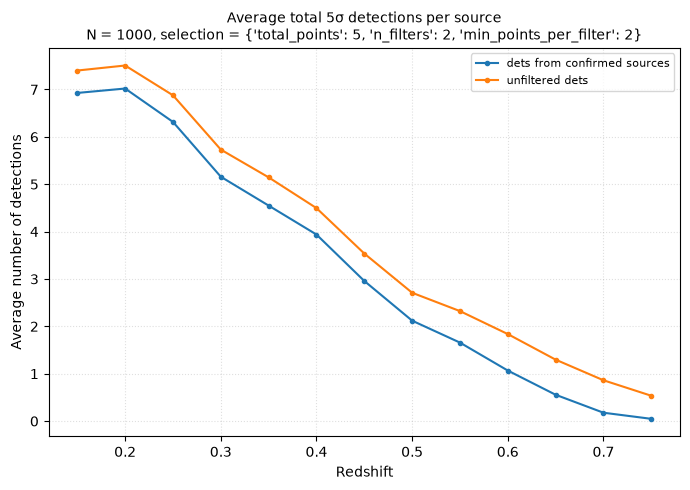

In [13]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(final_summary["z"], final_summary["n_det"]/1000, marker=".", label = 'dets from confirmed sources')
ax.plot(final_summary["z"], final_summary["n_det_unfiltered"]/1000, marker=".", label = 'unfiltered dets')

ax.set_xlabel("Redshift")
ax.set_ylabel("Average number of detections")
ax.set_title(
    f"Average total 5σ detections per source\n"
    f"N = {N_tot}, selection = {selection_criteria}",
    fontsize = 10
)
ax.legend(fontsize = 8)
ax.grid(alpha = 0.25, color = 'grey', linestyle = ':')

plt.tight_layout()
plt.show()

In [ ]:
N_tot = 1000

all_summaries = []

selection_criteria = set_selection_criteria(total_points=5,n_filters=2,min_points_per_filter=2)

redshifts = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

for redshift in redshifts:

    snia_dict = generate_snia_dict(redshift=redshift,ra=None,dec=None,x1=0.0,t0=None,magabs=-18.523,c=0.0)

    snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

    snia_models, data_models = generate_snia_lightcurve(
        *snia_param_list,
        bands=bands,
        in_mag=False,
        N_tot=N_tot,
        tstart = tmin - 100,
        tstop = tmax,
        zp=30,
        plot_curve=False,
        return_values=True,
        return_models=True,
        verbose=False
    )

    dset = skysurvey.DataSet.from_targets_and_survey(snia_models,lsst,progress_bar=True,discard_bands=True)

    total_results = 0
    unfiltered_detections = 0

    dset_target_indices = dset.data.index.get_level_values(0).unique().values

    for index in snia_models.data.index:
        if index in dset_target_indices:
            total_result = get_number_detections_allbands(dataset=dset,targets=snia_models,index=index,selection_criteria=selection_criteria)
            total_results += total_result
        else:
            pass

    unfiltered_detections = dset.get_ndetection().sum()
    total_summary = {"z": redshift, "n_det": total_results, "n_det_unfiltered": unfiltered_detections}

    for col in ["x1", "c", "t0", "magabs", "ra", "dec"]:
        total_summary[col] = snia_models.data[col].iloc[0]

    all_summaries.append(total_summary)

total_summary = pd.DataFrame(all_summaries)

print("\n All bands:")
print(total_summary)

100%|██████████| 695/695 [00:04<00:00, 152.36it/s]



 All bands:
       z  n_det  n_det_unfiltered   x1    c            t0     magabs  \
0   0.01   3347              3647  0.0  0.0  61395.660156 -18.523001   
1   0.05   9279              9682  0.0  0.0  61395.660156 -18.523001   
2   0.10   4449              4873  0.0  0.0  61395.660156 -18.523001   
3   0.20   3873              4158  0.0  0.0  61395.660156 -18.523001   
4   0.30   2110              2470  0.0  0.0  61395.660156 -18.523001   
5   0.40   2473              2888  0.0  0.0  61395.660156 -18.523001   
6   0.45    608              1106  0.0  0.0  61395.660156 -18.523001   
7   0.50    184               632  0.0  0.0  61395.660156 -18.523001   
8   0.55     39               381  0.0  0.0  61395.660156 -18.523001   
9   0.60      6               269  0.0  0.0  61395.660156 -18.523001   
10  0.65      0               139  0.0  0.0  61395.660156 -18.523001   
11  0.70      0                52  0.0  0.0  61395.660156 -18.523001   
12  0.75      0                16  0.0  0.0  61395.

In [96]:
snia_models.data

,z,x1,c,t0,magabs,ra,dec,magobs,template
0,0.8,0.0,0.0,61395.660156,-18.523001,78.535233,34.412609,25.041161,salt2
1,0.8,0.0,0.0,61139.242188,-18.523001,284.689636,-1.545068,25.041161,salt2
2,0.8,0.0,0.0,61410.855469,-18.523001,125.031082,-15.506495,25.041161,salt2
3,0.8,0.0,0.0,61134.250000,-18.523001,137.587021,-62.035633,25.041161,salt2
4,0.8,0.0,0.0,61299.753906,-18.523001,283.908661,29.575397,25.041161,salt2
...,...,...,...,...,...,...,...,...,...
995,0.8,0.0,0.0,61293.058594,-18.523001,43.165424,-35.095291,25.041161,salt2
996,0.8,0.0,0.0,61458.289062,-18.523001,347.745331,45.485550,25.041161,salt2
997,0.8,0.0,0.0,61548.343750,-18.523001,261.615143,31.615028,25.041161,salt2
998,0.8,0.0,0.0,61426.597656,-18.523001,117.788132,-69.011360,25.041161,salt2


In [77]:
dset.get_ndetection().sum()

np.int64(129)

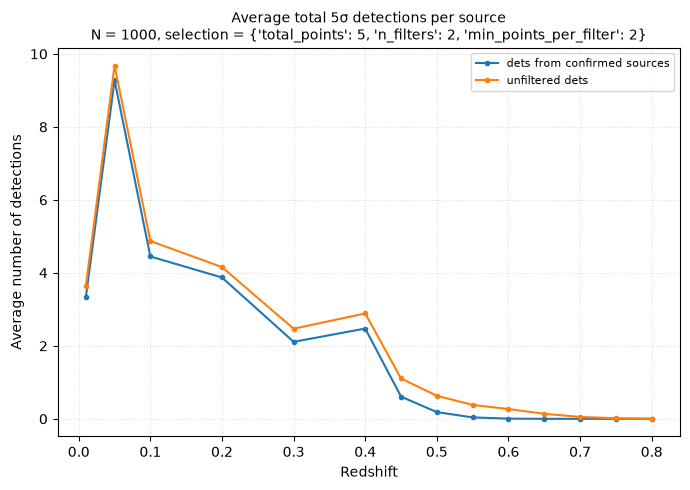

In [94]:
# plot TOTAL
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(total_summary["z"], total_summary["n_det"]/1000, marker=".", label = 'dets from confirmed sources')
ax.plot(total_summary["z"], total_summary["n_det_unfiltered"]/1000, marker=".", label = 'unfiltered dets')

ax.set_xlabel("Redshift")
ax.set_ylabel("Average number of detections")
ax.set_title(
    f"Average total 5σ detections per source\n"
    f"N = {N_tot}, selection = {selection_criteria}",
    fontsize = 10
)
ax.legend(fontsize = 8)
ax.grid(alpha = 0.25, color = 'grey', linestyle = ':')

plt.tight_layout()
plt.show()

In [ ]:
# now you need to randomise and put everything in a redshift bin.



In [ ]:
N_tot = 1000

all_summaries = []

selection_criteria = set_selection_criteria(total_points=5,n_filters=2,min_points_per_filter=2)

redshifts = [0.4]

for redshift in redshifts:

    snia_dict = generate_snia_dict(redshift=redshift,ra=None,dec=None,x1=0.0,t0=None,magabs=-18.523,c=0.0)

    snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

    snia_models, data_models = generate_snia_lightcurve(
        *snia_param_list,
        bands=bands,
        in_mag=False,
        N_tot=N_tot,
        tstart = tmin - 100,
        tstop = tmax,
        zp=30,
        plot_curve=False,
        return_values=True,
        return_models=True,
        verbose=False
    )

    dset = skysurvey.DataSet.from_targets_and_survey(snia_models,lsst,progress_bar=True,discard_bands=True)
    # Calculate detections for every target
    # band_results = []
    total_results = []

    dset_target_indices = dset.data.index.get_level_values(0).unique().values

    for index in snia_models.data.index:

        # if index in dset_target_indices:
        #     # keep only select sources that pass the criteria.
        #     band_result = get_number_detections_by_band(dataset=dset,targets=snia_models,index=index,selection_criteria=selection_criteria)
        # else:
        #     band_result = {'lsstu': 0,'lsstg': 0 , 'lsstr': 0 , 'lssti': 0 , 'lsstz': 0 ,'lssty': 0}

        # band_results.append(band_result)
            # Total detections across all bands
        if index in dset_target_indices:
            total_result = get_number_detections_allbands(dataset=dset,targets=snia_models,index=index,selection_criteria=selection_criteria)
            total_results.append(total_result)
        else:
            pass

    # --------------------------------------------------
    # Average per-band detections
    # --------------------------------------------------

    # band_summary = pd.DataFrame(band_results)
    # band_summary = band_summary.mean().to_dict()
    # band_summary["z"] = redshift

    # Log the SNIa parmeters. Flexible for fixed or varied params. Can be toggled off if needed.
    # for col in ["x1", "c", "t0", "magabs", "ra", "dec"]:
    #     band_summary[col] = snia_models.data[col].iloc[0]

    # band_summaries.append(band_summary)

    # --------------------------------------------------
    # Average total detections
    # --------------------------------------------------

    total_summary = {
        "z": redshift,
        "n_detections": np.mean(total_results),
    }

    # Fixed parameters
    for col in ["x1", "c", "t0", "magabs", "ra", "dec"]:
        total_summary[col] = snia_models.data[col].iloc[0]

    all_summaries.append(total_summary)

# --------------------------------------------------
# Combine all redshifts
# --------------------------------------------------

# band_summary = pd.DataFrame(band_summaries)
total_summary = pd.DataFrame(all_summaries)

# print("Per-band:")
# print(band_summary)

print("\nAll bands:")
print(total_summary)

100%|██████████| 684/684 [00:12<00:00, 52.97it/s] 


KeyError: 0

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for band in lsst_bands:
    ax.plot(
        band_summary["z"],
        band_summary[band],
        marker=".",
        label=band,
        color=limit_mag_dict[band]["color"],
    )

ax.set_xlabel("Redshift")
ax.set_ylabel("Average number of detections")
ax.set_title(
    f"Average 5σ detections per band\n"
    f"N = {N_tot}, selection = "
    f"{selection_criteria}"
)

ax.legend()
plt.tight_layout()
plt.show()

In [38]:
get_number_detections_band_five_sigma(dset, snia_models, index=30)


{'lsstu': 0, 'lsstg': 0, 'lsstr': 5, 'lssti': 5, 'lsstz': 1, 'lssty': 1}

In [166]:
get_number_detections_band_flux_limit(dset, snia_models, index=30)

{'lsstu': 0, 'lsstg': 0, 'lsstr': 3, 'lssti': 1, 'lsstz': 0, 'lssty': 0}

In [167]:
result = compare_ndetections_by_condition(dset, snia_models, index=30)
result

,condition,dec,ra,magabs,t0,c,x1,z,target,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,30,0,0,3,1,0,0
1,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,30,0,0,3,1,0,0


In [178]:
all_results = []

for index in snia_models.data.index:
    result = compare_ndetections_by_condition(dataset=dset,targets=snia_models,index=index)
    all_results.append(result)

all_results = pd.concat(all_results,ignore_index=True)
all_results

,condition,dec,ra,magabs,t0,c,x1,z,target,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,0,0,0,2,1,0,0
1,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,0,0,0,2,1,0,0
2,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,1,0,0,3,1,0,0
3,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,1,0,0,3,1,0,0
4,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,2,0,0,3,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,97,0,0,3,1,0,0
196,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,98,0,0,2,1,0,0
197,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,98,0,0,2,1,0,0
198,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,99,0,0,3,1,0,0


In [ ]:
all_results[
    (all_results["condition"] == "5_sigma") &
    (all_results["lsstr"] == 1) # seen in that particular filter
].head()

all_results.groupby("condition")[lsst_bands].sum()


,lsstu,lsstg,lsstr,lssti,lsstz,lssty
condition,,,,,,
5_sigma,0,0,273,99,0,0
5_sigma_flux_limit,0,0,273,98,0,0


In [ ]:
N_tot = 100

summary = (all_results.groupby("condition")[lsst_bands].sum().reset_index())

# Average number of detections per target
summary[lsst_bands] /= n_targets

# Parameters — assuming they are fixed across all targets
for col in ["z", "x1", "c", "t0", "magabs", "ra", "dec"]:
    summary[col] = all_results[col].iloc[0]

summary = summary[
    ["condition","z","x1","c","t0","magabs","ra","dec"] + lsst_bands
]

In [ ]:
for band in lsst_bands:
    print(summary[band][0]) # to get the values of cond1
    print(summary[band][1]) # to get the values of cond2 

IndexError: invalid index to scalar variable.

In [227]:
summary

,condition,z,x1,c,t0,magabs,ra,dec,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,5_sigma,0.6,0.0,0.0,61250.0,-18.523001,14.9,-22.4,0.0,0.0,1.81,0.06,0.0,0.0
1,5_sigma_flux_limit,0.6,0.0,0.0,61250.0,-18.523001,14.9,-22.4,0.0,0.0,0.01,0.00,0.0,0.0


In [213]:
N_tot = 100
for redshift in [0.2, 0.4, 0.6]:
    snia_dict = generate_snia_dict(redshift = redshift, ra = 14.9, dec = -22.4, x1 = 0.0, t0 = 61250.0, magabs = -18.523, c = 0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = False, N_tot = N_tot, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
    detection = dset.get_ndetection(per_band = True, join_bandday = False)

    N_tot = 100
    all_results = []

    for index in snia_models.data.index:
        result = compare_ndetections_by_condition(dataset=dset,targets=snia_models,index=index)
        all_results.append(result)

    all_results = pd.concat(all_results,ignore_index=True)
    all_results
    summary = (all_results.groupby("condition")[lsst_bands].sum().reset_index())

    # Average number of detections per target
    summary[lsst_bands] /= n_targets

    # Parameters — assuming they are fixed across all targets
    for col in ["z", "x1", "c", "t0", "magabs", "ra", "dec"]:
        summary[col] = all_results[col].iloc[0]

    summary = summary[
        ["condition","z","x1","c","t0","magabs","ra","dec"] + lsst_bands
    ]
    print(summary)

100%|██████████| 100/100 [00:14<00:00,  6.79it/s]


            condition    z   x1    c       t0     magabs    ra   dec  lsstu  \
0             5_sigma  0.2  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   
1  5_sigma_flux_limit  0.2  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   

   lsstg  lsstr  lssti  lsstz  lssty  
0    0.1   4.98   4.67   0.55   1.00  
1    0.1   4.98   3.98   0.15   0.29  


100%|██████████| 100/100 [00:03<00:00, 28.64it/s]


            condition    z   x1    c       t0     magabs    ra   dec  lsstu  \
0             5_sigma  0.4  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   
1  5_sigma_flux_limit  0.4  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   

   lsstg  lsstr  lssti  lsstz  lssty  
0    0.0   2.79   1.00    0.0   0.01  
1    0.0   2.79   0.94    0.0   0.00  


100%|██████████| 100/100 [00:03<00:00, 26.04it/s]


            condition    z   x1    c       t0     magabs    ra   dec  lsstu  \
0             5_sigma  0.6  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   
1  5_sigma_flux_limit  0.6  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   

   lsstg  lsstr  lssti  lsstz  lssty  
0    0.0   1.81   0.06    0.0    0.0  
1    0.0   0.01   0.00    0.0    0.0  


In [ ]:
N_tot = 100
all_summaries = []

for redshift in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]:

    snia_dict = generate_snia_dict(redshift=redshift, ra=14.9, dec=-22.4, x1=0.0, t0=61250.0, magabs=-18.523,c=0.0)

    snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

    snia_models, data_models = generate_snia_lightcurve(*snia_param_list,bands=bands,in_mag=False,N_tot=N_tot,zp=30,plot_curve=False,return_values=True,return_models=True,verbose=False)

    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst,progress_bar=True,discard_bands=True)

    # Get detection results for every target
    target_results = []

    for index in snia_models.data.index:

        result = compare_ndetections_by_condition(
            dataset=dset,
            targets=snia_models,
            index=index
        )

        target_results.append(result)

    target_results = pd.concat(
        target_results,
        ignore_index=True
    )

    # Sum detections over all targets
    summary = (
        target_results
        .groupby("condition")[lsst_bands]
        .sum()
        .reset_index()
    )

    # Convert to average number of detections per target
    summary[lsst_bands] /= N_tot

    # Add redshift
    summary["z"] = redshift

    # Add the other fixed parameters
    for col in ["x1", "c", "t0", "magabs", "ra", "dec"]:
        summary[col] = snia_models.data[col].iloc[0]

    # Keep useful column order
    summary = summary[
        [
            "condition",
            "z",
            "x1",
            "c",
            "t0",
            "magabs",
            "ra",
            "dec"
        ] + lsst_bands
    ]

    all_summaries.append(summary)

# Combine all redshifts
final_summary = pd.concat(
    all_summaries,
    ignore_index=True
)

print(final_summary)

100%|██████████| 100/100 [00:01<00:00, 73.10it/s]


             condition     z   x1    c       t0     magabs    ra   dec  lsstu  \
0              5_sigma  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   6.00   
1   5_sigma_flux_limit  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   6.00   
2              5_sigma  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   6.00   
3   5_sigma_flux_limit  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   6.00   
4              5_sigma  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1.01   
5   5_sigma_flux_limit  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1.01   
6              5_sigma  0.20  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
7   5_sigma_flux_limit  0.20  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
8              5_sigma  0.30  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
9   5_sigma_flux_limit  0.30  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
10             5_sigma  0.40  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
11  5_sigma_flux_limit  0.40

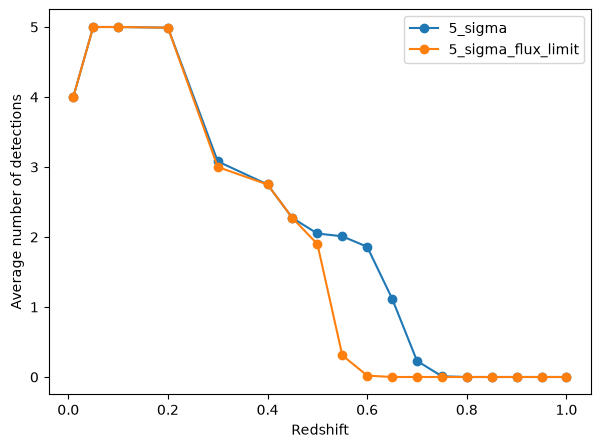

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for condition in ["5_sigma", "5_sigma_flux_limit"]:

    subset = final_summary[
        final_summary["condition"] == condition
    ]

    ax.plot(
        subset["z"],
        subset["lsstr"],
        marker="o",
        label=condition
    )

ax.set_xlabel("Redshift")
ax.set_ylabel("Average number of detections")
ax.legend()

plt.show()

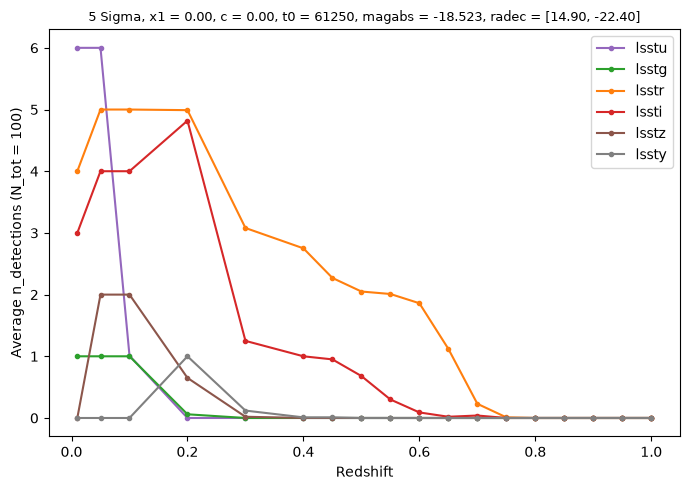

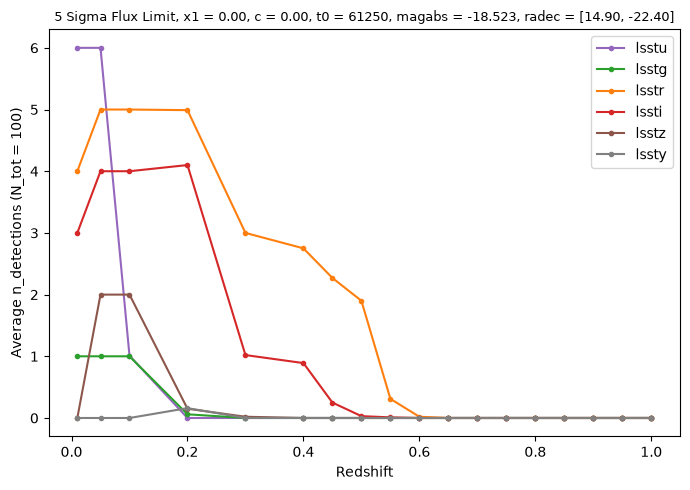

In [258]:
for condition in ["5_sigma", "5_sigma_flux_limit"]:

    fig, ax = plt.subplots(figsize=(7, 5))

    subset = final_summary[
        final_summary["condition"] == condition
    ]
    x1 = subset["x1"].iloc[0]
    c = subset["c"].iloc[0]
    t0 = subset["t0"].iloc[0]
    magabs = subset["magabs"].iloc[0]
    ra = subset["ra"].iloc[0]
    dec = subset["dec"].iloc[0]

    for band in lsst_bands:
        ax.plot(
            subset["z"],
            subset[band],
            marker=".",
            label=band,
            color=limit_mag_dict[band]["color"],
        )
        

    ax.set_xlabel("Redshift")
    ax.set_ylabel("Average n_detections (N_tot = {})".format(N_tot))
    ax.set_title(
        f"{condition.replace('_', ' ').title()}, "
        f"x1 = {x1:.2f}, c = {c:.2f}, "
        f"t0 = {t0:.0f}, magabs = {magabs:.3f}, "
        f"radec = [{ra:.2f}, {dec:.2f}]",
        fontsize=9,
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

In [233]:
ra_sn = 14.9
dec_sn = -22.4

ra_obs = lsst.data["ra"].astype(float)
dec_obs = lsst.data["dec"].astype(float)

# Approximate angular separation in degrees
cos_dec = np.cos(np.deg2rad(dec_sn))

distance = np.sqrt(
    ((ra_obs - ra_sn) * cos_dec)**2
    + (dec_obs - dec_sn)**2
)

nearby_obs = lsst.data[distance < 1.0].copy()

print(len(nearby_obs))

idx = distance.idxmin()

print(lsst.data.loc[idx, ["ra", "dec", "fieldid", "fieldid_survey"]])

fieldid = lsst.data.loc[idx, "fieldid"]

field_obs = lsst.data[
    lsst.data["fieldid"] == fieldid
].copy()

field_obs.groupby("band").size()

3222
ra                    14.914061
dec                  -22.415033
fieldid           325565.000000
fieldid_survey      6741.000000
Name: 747923, dtype: float64


band
lsstg     6
lssti    13
lsstr    14
lsstu     5
lssty     7
lsstz    10
dtype: int64

In [107]:
#loop targ (total 1000)
over_limit = 0
for idx in data.index:
    #if targ is visible, call visible
    detected = 
    summed = sum(targ['flux'] >= targ['band_limitflux']) #condition 1
    if summed 
    summed_total += summed
# dset.get_ndetection(per_band = True)[8] #using iloc will metely give you row in series
print(summed_total)

0


In [101]:
dset.data.index.get_level_values(level = 1).unique() #total 54000 observations on 1000 unique obejcts

Index([  747982,   884609,  2493070,  2770824,  2772648,  2860934,  3332454,
        3429213,  3623916,  3623971,  3876993,  3880803,  4038673,  4042244,
        4111433,  4171698,  4173233,  4279680,  4283154,  4427616,  4433288,
        4707663,  4708517,  5487127,  5718513,  5718593,  5936096,  6243399,
        6246427,  6618620,  6620433,  6852296,  6853041,  6853921,  7010817,
        7013607,  7961208,  7966181,  8002340,  8756533,  8758409,  9231240,
       11416749, 11418198, 11419647, 11421096, 11729192, 11730636, 11732080,
       11733524, 11873266, 11874731, 11876196, 11877661],
      dtype='int64', name='index_obs')

In [73]:
# initiate with all bands together first i.e. how many SNIas in your simulation are visible with LSST?
total_detections =  dset.get_ndetection(per_band = False, join_bandday=False)

In [76]:
n_obs = len(total_detections)
n_obs

997

In [22]:
z_list = [0.5, 0.6, 0.7, 0.8]
n_obs_list = []
for z in z_list:
    snia_dict = generate_snia_dict(redshift = z, ra = 14.9, dec = -22.4, x1 = 0.0, t0 = 61250, magabs = -18.523, c = 0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, N_tot = 100, tstart = None, tstop = None, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
    total_detections = dset.get_ndetection(per_band = False, join_bandday=False)
    n_obs = len(total_detections)
    n_obs_list.append(n_obs)

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 100/100 [00:05<00:00, 19.50it/s]


In [23]:
n_obs_list

[100, 100, 30, 0]

In [ ]:
z_list = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8]
n_obs = [49, 51, 50, 52, 41, 27, 1]

[0, 0]


Text(0.5, 1.0, 'N_tot = 100, 61208.20 to 61566.07 MJD, obstime 357.87d ')

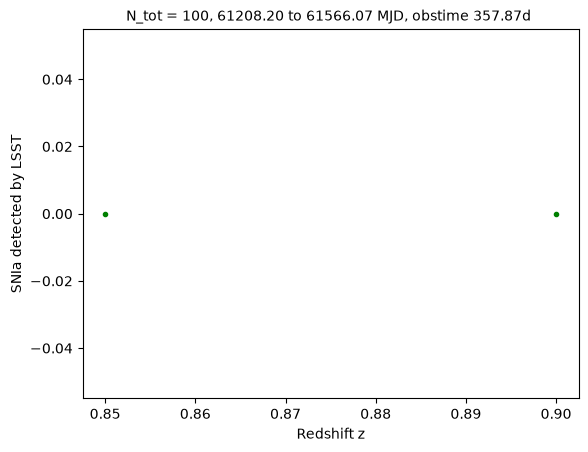

In [7]:
# This is the 3rd selection criteria with errors.
print(n_obs_list)
plt.plot(z_list, n_obs_list, 'g.', markersize = 6)
plt.xlabel('Redshift z')
plt.ylabel('SNIa detected by LSST')
plt.title(f'N_tot = 100, {tmin:.2f} to {tmax:.2f} MJD, obstime {(tmax - tmin):.2f}d', fontsize = 10)

In [ ]:
from scipy.optimize import curve_fit
z_range = np.linspace(0, 2, 100)
def line(x, m, c):
    y = m * x + c
    return y
p0 = [-1, 1]
po, cov = curve_fit(line, z_list, n_obs_list)
plt.plot(z_list, line(z_range, po[0], po[1]), 'r-')

In [143]:
coeffs = np.polyfit(z_list, n_obs_list, 3)
print(coeffs)

[  11.50464218 -122.8245962    31.10122292   49.07739941]


### Test all three selection criteria for one dset

In [20]:
snia_dict = generate_snia_dict(redshift = 0.7, ra = 40.2, dec = -22.3, x1 = 0.0, t0 = None, magabs = -18.523, c = 0.0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, N_tot = 100, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)

NameError: name 'tmin' is not defined

In [21]:
from pprint import pprint
series = dset.get_ndetection(per_band = True, join_bandday=False)
pprint(series)

NameError: name 'dset' is not defined

In [19]:
obs = dset.get_target_lightcurve()
obs[obs['band'] == 'lsstr'] #notice all the mjd time is different

NameError: name 'dset' is not defined

In [ ]:
# use series.loc[(1, "lsstr")] due to MultiIndex

np.int64(1)

In [37]:
z_list = [0.01, 0.05, 0.2, 0.4, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
n_obs_list = []

cbb_z = {'0.1': {'lsstu': 39,
  'lsstg': 40,
  'lsstr': 57,
  'lssti': 42,
  'lsstz': 46,
  'lssty': 0}}

for z in z_list:
    snia_dict = generate_snia_dict(redshift = z, ra = 40.2, dec = -22.3, x1 = 0.0, t0 = None, magabs = -18.523, c = 0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, N_tot = 200, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
    total_detections = dset.get_ndetection(per_band = False, join_bandday=False)
    n_obs = len(total_detections)
    n_obs_list.append(n_obs)
    series = dset.get_ndetection(per_band = True, join_bandday=False)
    df = series.reset_index(name="ndetection")
    # df.head()
    filter_dfs = {
        band: df[df["band"] == band].reset_index(drop=True) #this is the masking condition
        for band in ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
    }

    # Example: show counts per band
    counts_by_band = {band: len(frame) for band, frame in filter_dfs.items()} #this will be impt

    cbb_z[f'{z}'] = counts_by_band

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 200/200 [00:02<00:00, 66.86it/s] 
/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 200/200 [00:01<00:00, 130.87it/s]
/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 200/200 [00:03<00:00, 58.94it/s] 


In [50]:
cbb_z

{'0.1': {'lsstu': 39,
  'lsstg': 40,
  'lsstr': 57,
  'lssti': 42,
  'lsstz': 46,
  'lssty': 0},
 '0.01': {'lsstu': 92,
  'lsstg': 75,
  'lsstr': 104,
  'lssti': 77,
  'lsstz': 0,
  'lssty': 0},
 '0.05': {'lsstu': 92,
  'lsstg': 77,
  'lsstr': 102,
  'lssti': 79,
  'lsstz': 85,
  'lssty': 0},
 '0.2': {'lsstu': 44,
  'lsstg': 76,
  'lsstr': 105,
  'lssti': 76,
  'lsstz': 79,
  'lssty': 33},
 '0.4': {'lsstu': 0,
  'lsstg': 46,
  'lsstr': 85,
  'lssti': 54,
  'lsstz': 40,
  'lssty': 0},
 '0.6': {'lsstu': 0,
  'lsstg': 2,
  'lsstr': 45,
  'lssti': 7,
  'lsstz': 0,
  'lssty': 0},
 '0.7': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 5,
  'lssti': 2,
  'lsstz': 0,
  'lssty': 0},
 '0.75': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 3,
  'lssti': 0,
  'lsstz': 0,
  'lssty': 0},
 '0.8': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 0,
  'lssti': 0,
  'lsstz': 0,
  'lssty': 0},
 '0.85': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 0,
  'lssti': 0,
  'lsstz': 0,
  'lssty': 0},
 '0.9': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 0,

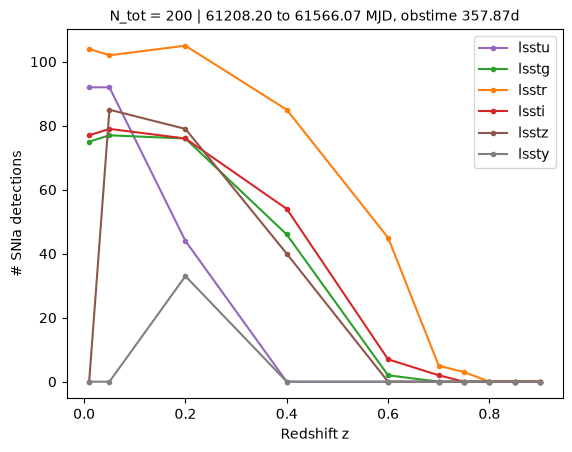

In [68]:
z_list = [0.01, 0.05, 0.2, 0.4, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
from lightcurve import limit_mag_dict
for band in bands:
    counts = [cbb_z[str(z)][band] for z in z_list]
    plt.plot(z_list, counts, marker=".", label=band, color = limit_mag_dict[band]["color"])

plt.xlabel("Redshift z")
plt.ylabel("# SNIa detections")
plt.title(f'N_tot = 200 | {tmin:.2f} to {tmax:.2f} MJD, obstime {(tmax - tmin):.2f}d', fontsize = 10)
plt.legend()
plt.show()

Find a SN with a lot of datapoints

We want to know on average, what are the number of detections per lightcurve per filter at a given z
So simulate random ra dec and take average.
For example, if we want min 3 datapoints in a filter, what is the max redshift we can look?

So good to fix a ra dec in a high res region.

In [15]:
# now each filter is a dict. This is for ONE redshift tho. This is still third criterion.
filter_dfs = {
    band: df[df["band"] == band].reset_index(drop=True) #this is the masking condition
    for band in ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
}

# Example: show counts per band
counts_by_band = {band: len(frame) for band, frame in filter_dfs.items()} #this will be impt
print(counts_by_band)

# Example: inspect the lsstr subset
filter_dfs["lsstg"]
for band in bands:
    print(band, filter_dfs[band].head()) 

# returns results:
print('\n redshift', 0.6,'\n', counts_by_band['lsstg'])


{'lsstu': 39, 'lsstg': 40, 'lsstr': 57, 'lssti': 42, 'lsstz': 46, 'lssty': 0}
lsstu    index   band  ndetection
0      0  lsstu           3
1      6  lsstu           2
2     10  lsstu           2
3     12  lsstu           2
4     13  lsstu           1
lsstg    index   band  ndetection
0      0  lsstg           2
1      6  lsstg           2
2      7  lsstg           2
3     10  lsstg           2
4     12  lsstg           2
lsstr    index   band  ndetection
0      0  lsstr           3
1      6  lsstr           6
2      7  lsstr           3
3      8  lsstr           3
4     10  lsstr           6
lssti    index   band  ndetection
0      0  lssti           1
1      6  lssti           1
2      7  lssti           2
3     10  lssti           2
4     12  lssti           2
lsstz    index   band  ndetection
0      0  lsstz           2
1      6  lsstz           4
2      7  lsstz           2
3     10  lsstz           6
4     12  lsstz           6
lssty Empty DataFrame
Columns: [index, band, ndetect

In [35]:
# store, for one redshift, the counts_by_band dict.
cbb_z = {}
cbb_z['0.1'] = counts_by_band

In [36]:
cbb_z

{'0.1': {'lsstu': 39,
  'lsstg': 40,
  'lsstr': 57,
  'lssti': 42,
  'lsstz': 46,
  'lssty': 0}}

In [33]:
for band, frame in filter_dfs.items():
    print(band)
    print(frame) #this is the larger dataset that records SNIa targets observed by LSST, with df index resetted

lsstu
    index   band  ndetection
0       0  lsstu           3
1       6  lsstu           2
2      10  lsstu           2
3      12  lsstu           2
4      13  lsstu           1
5      14  lsstu           1
6      18  lsstu           3
7      19  lsstu           2
8      21  lsstu           2
9      24  lsstu           1
10     28  lsstu           2
11     32  lsstu           2
12     33  lsstu           1
13     37  lsstu           2
14     39  lsstu           1
15     40  lsstu           1
16     41  lsstu           3
17     42  lsstu           1
18     43  lsstu           1
19     49  lsstu           3
20     56  lsstu           3
21     57  lsstu           1
22     58  lsstu           1
23     60  lsstu           2
24     61  lsstu           1
25     65  lsstu           4
26     66  lsstu           3
27     68  lsstu           1
28     69  lsstu           2
29     73  lsstu           2
30     74  lsstu           2
31     75  lsstu           1
32     76  lsstu           3
33     7

In [ ]:
determine_visibility()

,index,band,ndetection
0,1,lssti,1
1,1,lsstr,1


In [111]:


print(series.iloc[27])
index = series.index[0]
band_index = series.index[1]
print('max in series.values is', np.max(series.values))
np.argwhere(series.values == np.max(series.values))
# series.iloc[27]
# np.where(series.index

1
max in series.values is 3


array([[   9],
       [  10],
       [  24],
       [  32],
       [  35],
       [  61],
       [  66],
       [  73],
       [ 104],
       [ 115],
       [ 129],
       [ 133],
       [ 156],
       [ 191],
       [ 204],
       [ 235],
       [ 272],
       [ 282],
       [ 329],
       [ 333],
       [ 348],
       [ 350],
       [ 354],
       [ 366],
       [ 384],
       [ 387],
       [ 415],
       [ 425],
       [ 426],
       [ 438],
       [ 439],
       [ 478],
       [ 525],
       [ 559],
       [ 610],
       [ 615],
       [ 628],
       [ 674],
       [ 718],
       [ 729],
       [ 757],
       [ 763],
       [ 782],
       [ 822],
       [ 847],
       [ 861],
       [ 865],
       [ 877],
       [ 880],
       [ 900],
       [ 931],
       [ 942],
       [ 946],
       [ 954],
       [ 971],
       [ 982],
       [1002],
       [1010],
       [1020],
       [1027],
       [1073],
       [1091],
       [1102],
       [1112],
       [1117],
       [1131],
       [11

In [218]:
help(dset.show_target_lightcurve)

Help on method show_target_lightcurve in module skysurvey.dataset:

show_target_lightcurve(
    ax=None,
    fig=None,
    index=None,
    zp=25,
    lc_prop={},
    bands=None,
    show_truth=True,
    format_time=True,
    t0_format='mjd',
    phase_window=None,
    **kwargs
) method of skysurvey.dataset.DataSet instance
    Plot the light curve of a target.

    If `index` is None, a random index will be used. If `bands` is None,
    the target's observed band will be used.

    Parameters
    ----------
    ax : matplotlib.axes.Axes, optional
        The axes on which to plot the light curve. If None, a new figure and axes will be created.

    fig : matplotlib.figure.Figure, optional
        The figure on which to plot the light curve. If None, a new figure will be created.

    index : int, optional
        The index of the target whose light curve is to be plotted. If None, a random index is chosen.

    zp : float, optional
        Zero point magnitude for flux conversion. Defa

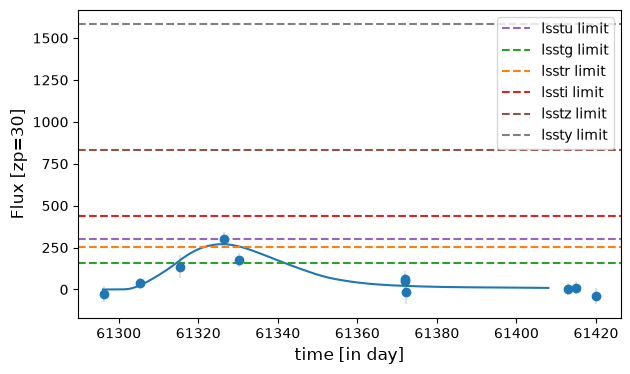

In [ ]:
# detectopm = 5sigma
# fig, ax = plt.subplots(1,1)
dset.show_target_lightcurve(index = 1, phase_window=[-60,200], zp = 30, bands = ['lsstr'], format_time = False)
# plt.xlim(61321, 61322)
ax = plt.gca()
for band in bands:
    ax.axhline(
        limit_mag_dict[band]["flux"],
        color=limit_mag_dict[band]["color"],
        linestyle="--",
        label=f"{band} limit",
    )
ax.legend()
# ax.set_ylim(163,164)
# ax.set_xlim(61312, 61318)

#recall the phase range is the range within we define our model lightcurve

In [64]:
# Criteria 1: Is it observable? Perhaps include this column in a combined parquet with the Criteria 3.
z_list = [0.1]
n_obs_list_test = []
cbb_z_test = {}

for z in z_list:
    snia_dict = generate_snia_dict(redshift = z, ra = 40.2, dec = -22.3, x1 = 0.0, t0 = None, magabs = -18.523, c = 0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, N_tot = 200, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
    total_detections = dset.get_ndetection(per_band = False, join_bandday=False)
    n_obs = len(total_detections)
    n_obs_list_test.append(n_obs)
    series = dset.get_ndetection(per_band = True, join_bandday=False)
    df = series.reset_index(name="ndetection")
    # df.head()
    filter_dfs = {
        band: df[df["band"] == band].reset_index(drop=True) #this is the masking condition
        for band in ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
    }

    # Example: show counts per band
    counts_by_band = {band: len(frame) for band, frame in filter_dfs.items()} #this will be impt

    cbb_z_test[f'{z}'] = counts_by_band

snia_models.data

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 200/200 [00:02<00:00, 84.82it/s] 


,z,x1,c,t0,magabs,ra,dec,magobs,template
0,0.1,0.0,0.0,61396.839844,-18.523001,40.200001,-22.299999,19.864223,salt2
1,0.1,0.0,0.0,61536.656250,-18.523001,40.200001,-22.299999,19.864223,salt2
2,0.1,0.0,0.0,61478.531250,-18.523001,40.200001,-22.299999,19.864223,salt2
3,0.1,0.0,0.0,61238.214844,-18.523001,40.200001,-22.299999,19.864223,salt2
4,0.1,0.0,0.0,61516.699219,-18.523001,40.200001,-22.299999,19.864223,salt2
...,...,...,...,...,...,...,...,...,...
195,0.1,0.0,0.0,61429.542969,-18.523001,40.200001,-22.299999,19.864223,salt2
196,0.1,0.0,0.0,61329.675781,-18.523001,40.200001,-22.299999,19.864223,salt2
197,0.1,0.0,0.0,61339.203125,-18.523001,40.200001,-22.299999,19.864223,salt2
198,0.1,0.0,0.0,61252.144531,-18.523001,40.200001,-22.299999,19.864223,salt2


In [66]:
data_models[1]

{'times': array([61516.65625   , 61516.79653056, 61516.93681112, 61517.07709168,
        61517.21737224, 61517.35765281, 61517.49793337, 61517.63821393,
        61517.77849449, 61517.91877505, 61518.05905561, 61518.19933617,
        61518.33961673, 61518.47989729, 61518.62017786, 61518.76045842,
        61518.90073898, 61519.04101954, 61519.1813001 , 61519.32158066,
        61519.46186122, 61519.60214178, 61519.74242234, 61519.88270291,
        61520.02298347, 61520.16326403, 61520.30354459, 61520.44382515,
        61520.58410571, 61520.72438627, 61520.86466683, 61521.00494739,
        61521.14522796, 61521.28550852, 61521.42578908, 61521.56606964,
        61521.7063502 , 61521.84663076, 61521.98691132, 61522.12719188,
        61522.26747244, 61522.40775301, 61522.54803357, 61522.68831413,
        61522.82859469, 61522.96887525, 61523.10915581, 61523.24943637,
        61523.38971693, 61523.52999749, 61523.67027806, 61523.81055862,
        61523.95083918, 61524.09111974, 61524.2314003 ,

In [43]:
# perhaps optional: for every index (prob very heavy)
obs = dset.get_target_lightcurve(index=3)
print(obs.columns)
print(obs[["band", "mjd", "flux", "fluxerr", "zp"]])

NameError: name 'dset' is not defined

In [41]:
from skysurvey.config import get_band_color

bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]

print(get_band_color(bands))

[None, None, None, None, None, None]


In [185]:
print(obs[obs["band"] == "lssti"])

                    mjd   band    skynoise  gain  zp  fieldid        flux  \
index_obs                                                                   
4498081    61315.335938  lssti   70.519104     1  30   331110  163.660189   
5136919    61324.378906  lssti   84.697784     1  30   331110  397.150022   
5372465    61330.222656  lssti   54.827576     1  30   331110  320.206969   
5849996    61343.273438  lssti   70.383858     1  30   331110  136.535177   
7023889    61366.191406  lssti  134.558014     1  30   331110  -45.206746   
8394570    61394.128906  lssti   68.646149     1  30   331110   16.971908   

              fluxerr  
index_obs              
4498081     71.761836  
5136919     86.335941  
5372465     57.344048  
5849996     71.724453  
7023889    134.778585  
8394570     68.819681  


NameError: name 'dset' is not defined

In [192]:
obs = dset.get_data(index=1, zp=30).copy()

obs["threshold"] = 5 * obs["fluxerr"]
obs

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr,threshold
index_obs,,,,,,,,,
2596757,61251.386719,lssty,202.305313,1,30,331110,193.632987,202.305317,1011.526586
3549467,61294.410156,lsstz,199.521988,1,30,331110,46.530186,199.521987,997.609937
3719679,61296.406250,lsstr,46.684544,1,30,331110,-26.502474,46.684681,233.423403
4187965,61303.230469,lssty,278.196136,1,30,331110,101.359442,278.219190,1391.095948
4190428,61303.238281,lssty,307.322113,1,30,331110,-304.455674,307.343059,1536.715296
4210849,61304.246094,lssty,190.099640,1,30,331110,99.934681,190.152483,950.762417
4211066,61304.246094,lssty,191.964066,1,30,331110,-124.436517,192.016393,960.081963
4211468,61304.246094,lssty,186.095703,1,30,331110,-184.018410,186.149674,930.748372
4293692,61305.234375,lsstz,96.023933,1,30,331110,133.212880,96.201525,481.007623


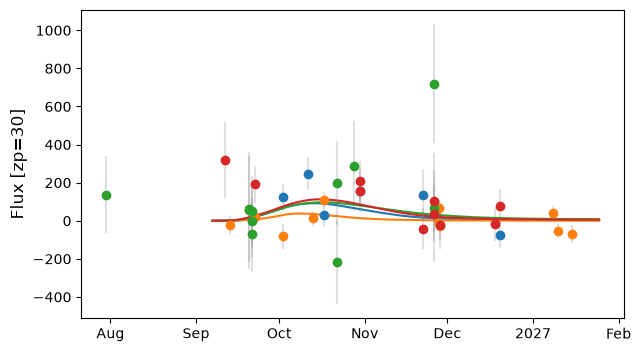

In [ ]:
# detectopm = 5sigma
fig = dset.show_target_lightcurve(index=0, phase_window=None, zp = 30)

In [ ]:
from skysurvey.config import get_band_color

import inspect

print(inspect.getsource(get_band_color))

In [77]:
# flux to mag using zpf = 25: result[i] = -2.5 * np.log10(f / zpf)

#zpf =/= zp = 25

import numpy as np

def flux_to_mag(flux, zp=30):
    return zp - 2.5*np.log10(flux)

def mag_to_flux(mag, zp=30):
    return 10**(-0.4*(mag-zp))

In [78]:
limit_mag_dict = {
    "lsstu": {"mag": 23.8, "color": "tab:purple"},
    "lsstg": {"mag": 24.5, "color": "tab:green"},
    "lsstr": {"mag": 24.0, "color": "tab:orange"},
    "lssti": {"mag": 23.4, "color": "tab:red"},
    "lsstz": {"mag": 22.7, "color": "tab:brown"},
    "lssty": {"mag": 22.0, "color": "0.5"},
}

# Convert each band limit from magnitude to flux using zp=30
limit_flux_dict = {
    band: {
        "mag": info["mag"],
        "flux": round(mag_to_flux(info["mag"], zp=30), 3),
        "color": info["color"],
    }
    for band, info in limit_mag_dict.items()
}

limit_flux_dict

{'lsstu': {'mag': 23.8, 'flux': 301.995, 'color': 'tab:purple'},
 'lsstg': {'mag': 24.5, 'flux': 158.489, 'color': 'tab:green'},
 'lsstr': {'mag': 24.0, 'flux': 251.189, 'color': 'tab:orange'},
 'lssti': {'mag': 23.4, 'flux': 436.516, 'color': 'tab:red'},
 'lsstz': {'mag': 22.7, 'flux': 831.764, 'color': 'tab:brown'},
 'lssty': {'mag': 22.0, 'flux': 1584.893, 'color': '0.5'}}